# [기말 과제] 와인 품질 예측

**작성자**: 김준  
**날짜**: 2025-11-28

## 1. 요구사항 및 목표

**과제 요구 사항**:
* 가능하면 적은 갯수의 필드로 Quality를 예측합니다.
* Quality 예측이 잘 되었는지 평가하는 기계학습 성능지표를 잘 선정해야 합니다.
* 학생이 선호하는 기계학습 알고리즘을 사용합니다.
* 사용하는 알고리즘이 파라미터를 많이 사용하는 것이라면, mlflow를 활용하는 것을 권장합니다.
* mlflow 사용했을 경우, mlruns 폴더 전체를 zip 파일로 archive 하여 제출합니다.
* 4000여개의 데이터를 제공하였고, 학생의 성과는 제공되지 않은 900여개의 데이터로 평가합니다.
* 간혹 이상치가 있을 수 있으니, 이상치를 제거하는 전처리 작업도 시행하여야 합니다

**목표**: 
* **데이터 엔지니어링 + 기계학습 + 설명 및 분석**
* `wine_data_homework.csv` 데이터를 활용하여 와인의 품질(Quality)을예측하는 모델을 개발하는 것을 목표로 합니다. 
* 단순한 모델링을 넘어, 데이터의 통계적 특성을 분석하고 양조학적 도메인지식을 활용한 피처 엔지니어링, 그리고 MLflow를 활용한 체계적인 실험 관리를수행합니다. 
* 각 단계의 의사결정 과정을 투명하게 시각화하여 논리적 타당성을 확보합니다.

### 1.1 핵심 요구사항 및 해결 전략

1.  **Deep EDA**: 단순 분포 확인을 넘어, 품질(Quality) 등급별 변수의 차이를 `Boxplot`과 `KDE Plot`으로 비교 분석합니다.
2.  **이상치 처리**: 데이터의 노이즈를 줄이기 위해 IQR 및 Isolation Forest 기법을 비교 분석하여 최적의 이상치 제거 전략을 수립합니다.이상치 제거 전후의 데이터 손실과 분포 개선의 트레이드오프를 확인합니다.
3.  **최소한의 피처 사용**: 다중공선성(Multicollinearity)을 피하고 모델의 일반화 성능을 높이기 위해 중요 변수(Feature Importance)를 선별합니다.
4.  **MLflow 활용**: 하이퍼파라미터 튜닝 과정과 실험 결과를 MLflow로 추적하여 모델의 재현성을 확보합니다.
5.  **일반화 성능 확보**: 과적합(Overfitting)을 방지하기 위해 교차 검증(Cross Validation)과 홀드아웃 테스트 셋을 엄격히 분리합니다.
6.  **Model Evaluation**: 예측 결과의 잔차(Residual) 패턴과 혼동 행렬(Confusion Matrix)을 시각화하여 모델의 약점을 파악합니다.
7.  **최종 검증**: 제공된 `wine-quality_searched.csv`의 특정 구간(4001~4897행)을 사용하여 최종 모델의 성능을 평가합니다.

### 1.2 전체 분석 파이프라인 (Process Architecture)

데이터 로드 -> 데이터 확인 -> 


1.  **Data Loading & Split**: 데이터 로드 및 Train/Test 분리 (Data Leakage 원천 차단)
2.  **Deep EDA**: 분포 확인, 상관관계 분석, 시각화를 통한 인사이트 도출
3.  **Outlier Detection**: IQR vs Isolation Forest 비교 실험 및 적용
4.  **Feature Engineering**: 도메인 기반 파생 변수 생성 및 검증
5.  **Preprocessing**: Scaling, Encoding, Imbalance Handling (SMOTE)
6.  **Modeling & Optimization**: MLflow 기반 모델 비교 (ElasticNet, RF, XGBoost)
7.  **Evaluation & Interpretation**: SHAP 분석 및 잔차 분석
8.  **Final Deployment**: 히든 테스트 셋에 대한 최종 예측

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import mlflow
import mlflow.sklearn

# 머신러닝 및 전처리 관련 라이브러리
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# 시각화 설정 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정
plt.rc('axes', unicode_minus=False)
warnings.filterwarnings('ignore')

# 재현성을 위한 시드 고정
SEED = 42
np.random.seed(SEED)

# MLflow 설정 (로컬 저장소 사용)
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Wine_Quality_Expert_Viz")

# 1. 데이터 로드
try:
    df_train_full = pd.read_csv('wine_data_homework.csv')
    # 인덱스 컬럼 처리
    if df_train_full.columns[0] == 'Unnamed: 0' or df_train_full.iloc[:,0].is_monotonic_increasing:
        df_train_full = df_train_full.drop(df_train_full.columns[0], axis=1)
    print("데이터 로드 완료. Shape:", df_train_full.shape)
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

print("\n=== 기본 통계 정보 ===")
print(df_train_full.head())

데이터 로드 완료. Shape: (4001, 12)

=== 기본 통계 정보 ===
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8       

In [2]:
# 기본 정보 확인
df_train_full.info()
# 결측치 확인
print("=== 데이터 결측치 확인 ===")
missing_values = df_train_full.isnull().sum()
print("\nMissing Values per Column:")
print(missing_values[missing_values > 0])

if missing_values.sum() > 0:
    print(f"\n총 결측치: {missing_values.sum()}개")
else:
    print("\n결측치가 없습니다.")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4001 non-null   float64
 1   volatile acidity      4001 non-null   float64
 2   citric acid           4001 non-null   float64
 3   residual sugar        4001 non-null   float64
 4   chlorides             4001 non-null   float64
 5   free sulfur dioxide   4001 non-null   float64
 6   total sulfur dioxide  4001 non-null   float64
 7   density               4001 non-null   float64
 8   pH                    4001 non-null   float64
 9   sulphates             4001 non-null   float64
 10  alcohol               4001 non-null   float64
 11  quality               4001 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 375.2 KB
=== 데이터 결측치 확인 ===

Missing Values per Column:
Series([], dtype: int64)

결측치가 없습니다.


In [3]:
# 2. Train/Test Split (Data Leakage 방지)
# Stratified Split을 사용하여 Quality 분포를 유지하며 분리
X = df_train_full.drop('quality', axis=1)
y = df_train_full['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("\n=== Train/Test Split 결과 ===")
print(f"Train Set: {X_train.shape}, Test Set: {X_test.shape}")


=== Train/Test Split 결과 ===
Train Set: (3200, 11), Test Set: (801, 11)


## 2. 심화 탐색적 데이터 분석 (Advanced EDA)

단순한 분포 확인을 넘어, 각 피처가 품질(Quality) 결정에 미치는 영향을 시각적으로 파헤칩니다.

In [13]:
def plot_target_distribution(y_data, title="타겟 변수 분포 분석", xlabel="Quality Score", ylabel="Count", figsize=(10, 5), palette='viridis'):
    """
    타겟 변수의 분포를 Count Plot으로 시각화하고, 각 클래스의 비율(%)을 표시합니다.

    Args:
        y_data (pd.Series or np.array): 시각화할 타겟 변수 데이터 (e.g., y_train).
        title (str): 그래프의 제목.
        xlabel (str): x축 레이블.
        ylabel (str): y축 레이블.
        figsize (tuple): 그래프의 크기.
        palette (str): Seaborn 색상 팔레트.
    """
    if not isinstance(y_data, pd.Series):
        try:
            # y_data가 Series가 아니면 Series로 변환 시도
            y_data = pd.Series(y_data)
        except:
            print("오류: y_data는 pandas Series 또는 Series로 변환 가능한 형태여야 합니다.")
            return

    plt.figure(figsize=figsize)
    
    # 1. Count Plot 생성
    ax = sns.countplot(x=y_data, palette=palette)
    
    # 2. 막대 위에 비율(%) 표시
    total = len(y_data)
    for p in ax.patches:
        height = p.get_height()
        # 높이가 0이 아닌 경우에만 비율을 계산하고 표시
        if height > 0:
            percentage = '{:.1f}%'.format(100 * height / total)
            # x 좌표: 막대의 중앙
            x = p.get_x() + p.get_width() / 2
            # y 좌표: 막대 끝에서 약간 위에 위치
            y = height
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

    # 3. 제목 및 레이블 설정
    plt.title(f'{title} - 클래스 불균형 확인', fontsize=15)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

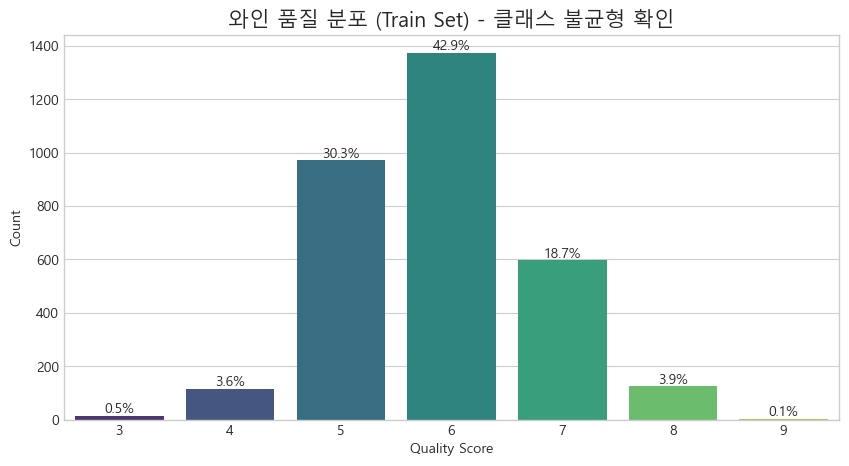

In [14]:
plot_target_distribution(y_train, 
                         title="와인 품질 분포 (Train Set)", 
                         xlabel="Quality Score")

### 분석: Quality 분포 시각화 결과
- **시각화 해석**: 위 그래프는 데이터의 클래스 불균형을 명확히 보여줍니다. 6점이 가장 많고 5점, 7점 순이며, **3, 4, 8, 9점은 극소수**입니다.
- **결론**: 이러한 불균형을 해결하지 않고 모델을 학습하면 다수 클래스(5, 6, 7)로 편향될 것입니다. 따라서 후속 단계에서 **SMOTE 계열의 오버샘플링이 필수적**임을 시각적으로 확인했습니다.

In [17]:
# 피처별 Quality 구분 능력 분석 (Boxplot)
def plot_feature_quality_boxplots(X_data, y_data, n_cols=3, figsize_per_row=5):
    """
    각 독립 변수(Feature)가 타겟 변수(Quality)에 따라 어떻게 분포하는지 Boxplot으로 시각화합니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
        n_cols (int): 한 행에 표시할 서브플롯의 개수. 기본값은 3.
        figsize_per_row (int): 한 행당 높이 비율을 결정하는 값. (전체 높이 = n_rows * figsize_per_row)
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return
    
    features = X_data.columns
    n_features = len(features)
    # 필요한 행의 개수 계산
    n_rows = (n_features + n_cols - 1) // n_cols

    # 전체 Figure 크기 설정
    plt.figure(figsize=(20, figsize_per_row * n_rows))

    print(f"총 {n_features}개의 피처에 대해 Quality별 Boxplot을 생성합니다.")

    # 각 피처에 대해 반복하며 서브플롯 생성
    for i, col in enumerate(features):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Boxplot으로 중앙값과 분포 비교
        # x축은 타겟 변수, y축은 현재 피처
        sns.boxplot(x=y_data, y=X_data[col], palette='coolwarm')
        
        plt.title(f'{col} vs Quality', fontsize=14, fontweight='bold')
        plt.xlabel('Quality Score')
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

총 11개의 피처에 대해 Quality별 Boxplot을 생성합니다.


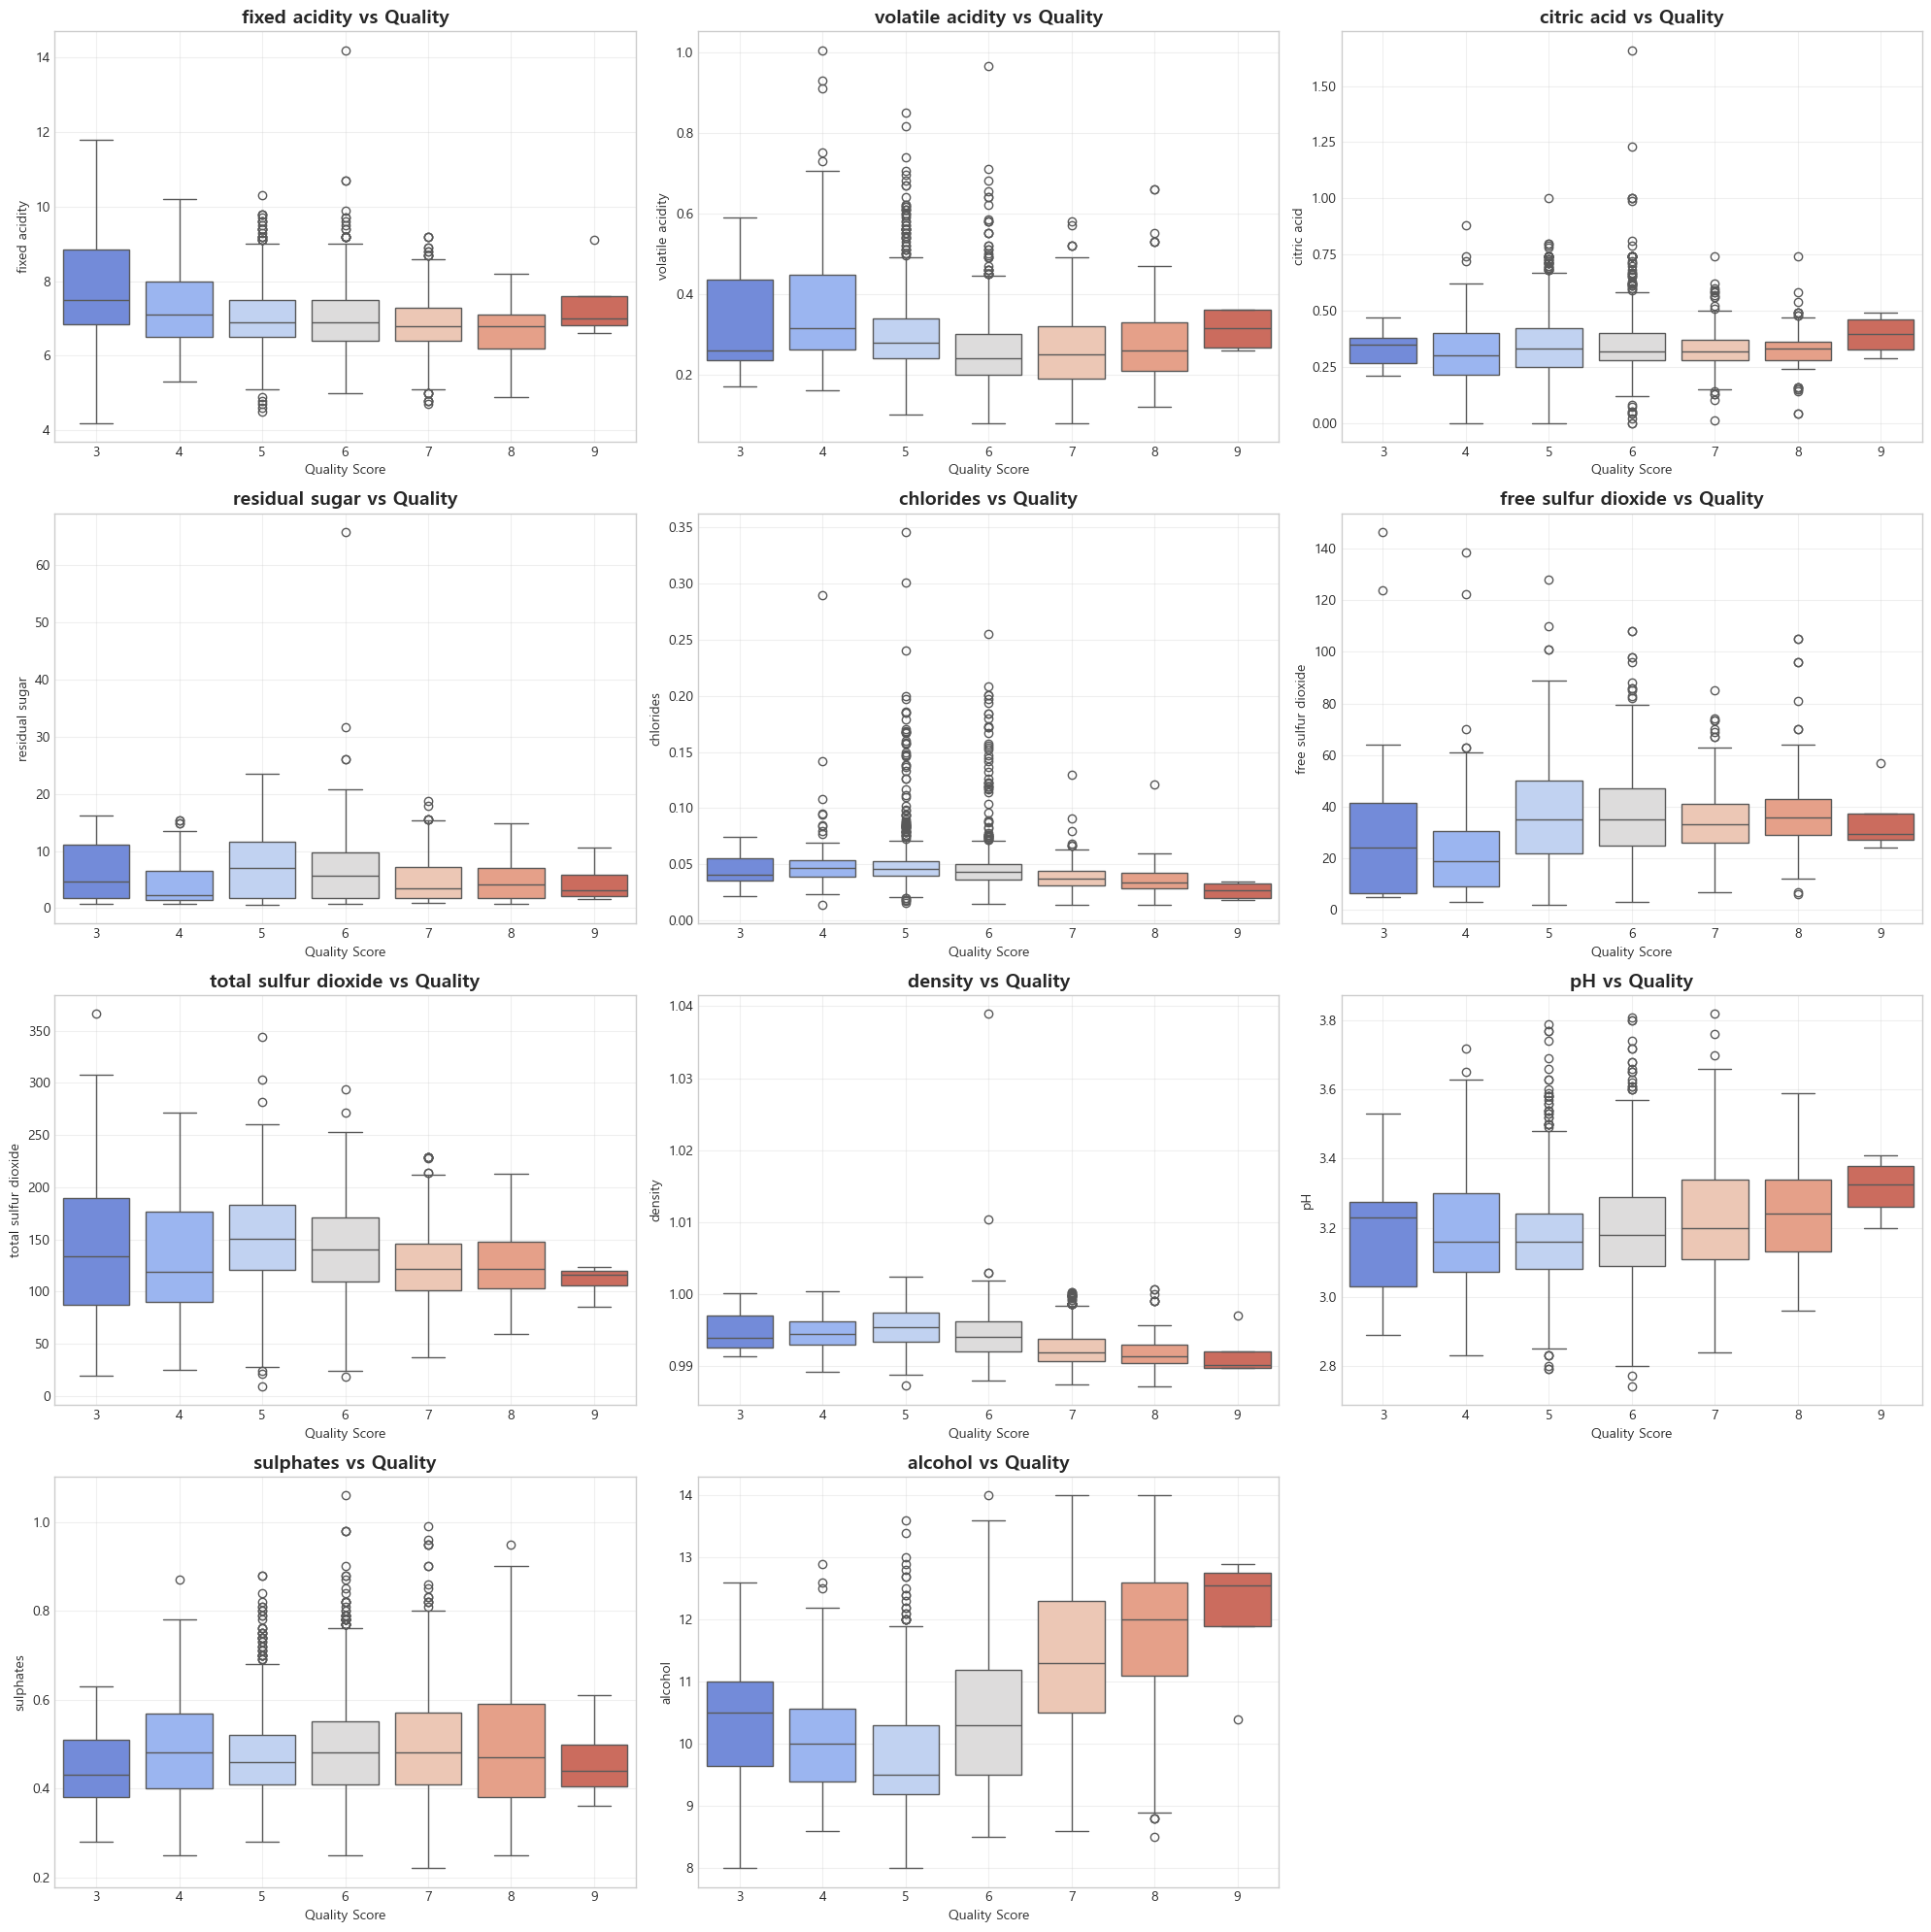

In [ ]:

# 함수 실행
plot_feature_quality_boxplots(X_train, y_train)

### 분석: Boxplot을 통한 변수별 영향력 확인
- **Alcohol**: Quality가 높아질수록(오른쪽으로 갈수록) Box의 위치가 상승하는 경향이 뚜렷합니다. 이는 **가장 강력한 예측 변수**임을 암시합니다.
- **Density**: Alcohol과 반대로 Quality가 높을수록 낮아지는 경향을 보입니다. (Alcohol과 Density는 음의 상관관계가 높기 때문)
- **Volatile Acidity**: 품질이 나쁜 와인(3, 4점)에서 수치가 높게 나타나며, 품질이 좋을수록 낮아집니다. 이는 식초 냄새(휘발성 산)가 품질 저하의 원인임을 보여줍니다.
- **결론**: 단순히 모든 변수를 넣기보다, Boxplot에서 등급 간 차이가 뚜렷한 변수(Alcohol, Volatile Acidity 등)가 모델에서 높은 중요도를 가질 것으로 예상됩니다.

In [19]:
# 수치형 변수들의 분포 (Histogram & KDE)
def plot_numerical_distribution(X_data, n_cols=3, bins=30, color='skyblue', figsize_per_row=4):
    """
    수치형 독립 변수들의 분포를 히스토그램과 KDE 플롯으로 시각화합니다.
    
    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        n_cols (int): 한 행에 표시할 서브플롯의 개수. 기본값은 3.
        bins (int): 히스토그램의 막대(bin) 개수.
        color (str): 플롯의 색상.
        figsize_per_row (int): 한 행당 높이 비율을 결정하는 값.
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return
        
    # 수치형 변수만 선택
    # 와인 데이터셋은 보통 모든 피처가 수치형이지만, 안전을 위해 필터링
    numerical_features = X_data.select_dtypes(include=np.number).columns
    
    if numerical_features.empty:
        print("오류: X_data에 시각화할 수 있는 수치형 변수가 없습니다.")
        return

    n_features = len(numerical_features)
    # 필요한 행의 개수 계산
    n_rows = (n_features + n_cols - 1) // n_cols

    # 전체 Figure 크기 설정
    plt.figure(figsize=(20, figsize_per_row * n_rows))
    
    print(f"총 {n_features}개의 수치형 피처 분포를 생성합니다.")

    # 각 피처에 대해 반복하며 서브플롯 생성
    for i, col in enumerate(numerical_features):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Histplot 생성 (kde=True로 KDE 곡선 함께 표시)
        sns.histplot(X_data[col], kde=True, bins=bins, color=color)
        
        plt.title(f'{col} Distribution', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Density / Count')
        
    plt.tight_layout()
    plt.show()

총 11개의 수치형 피처 분포를 생성합니다.


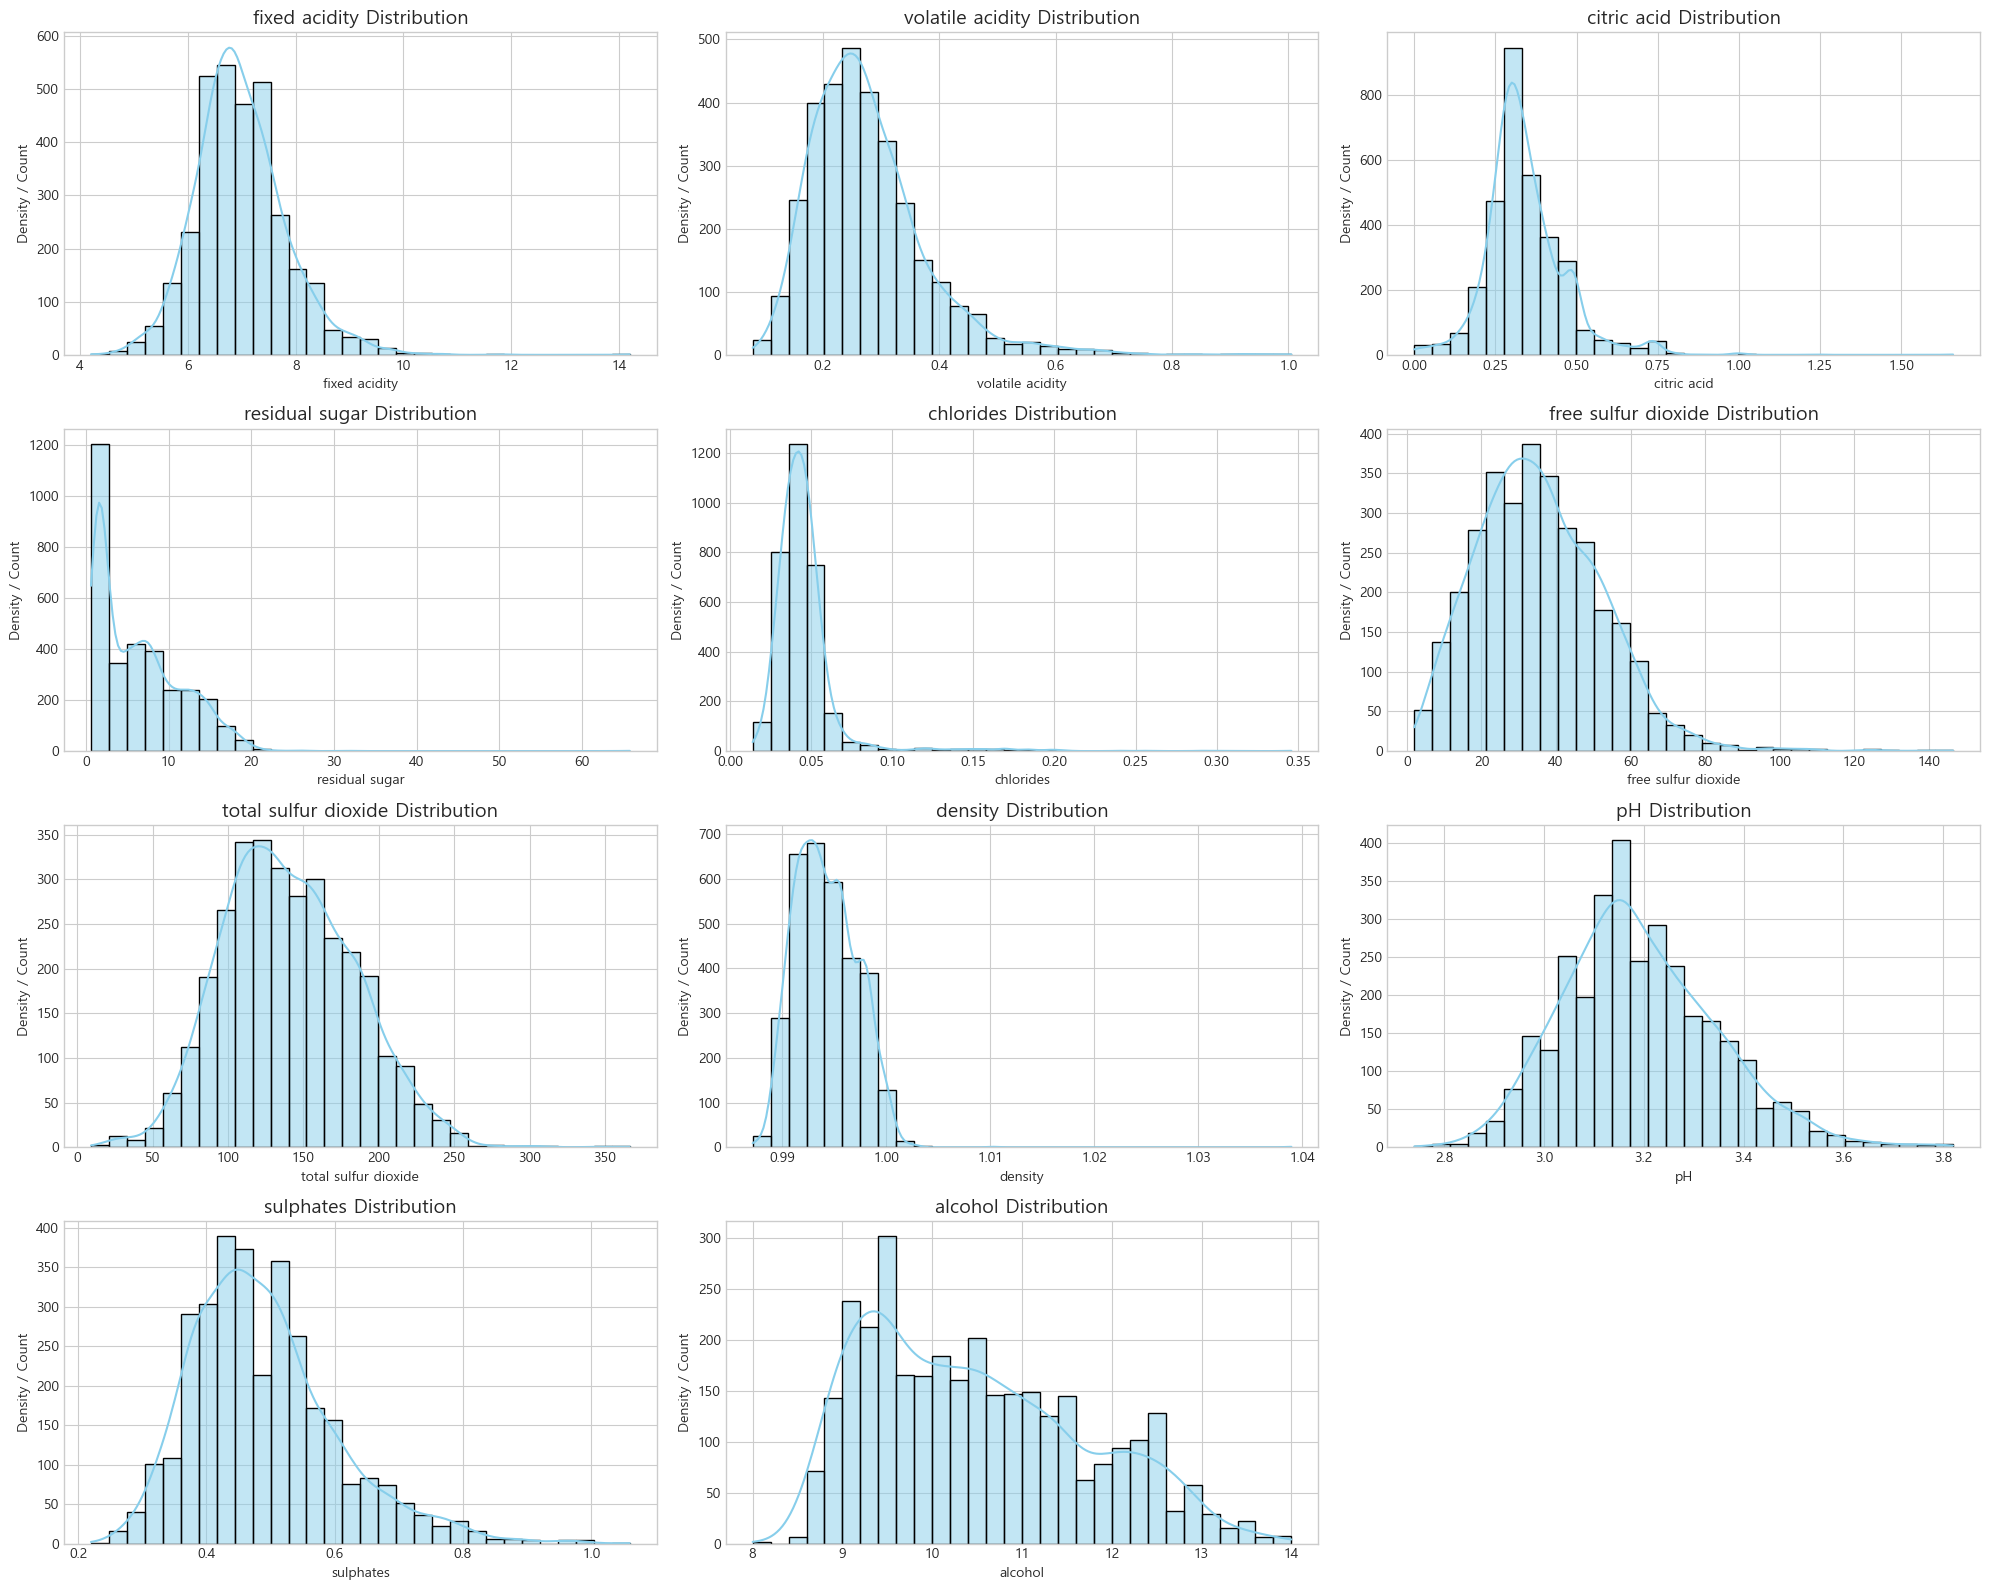

In [20]:
# 함수 실행
plot_numerical_distribution(X_train)

### 분석: 데이터 분포 확인
- **불균형 데이터**: `residual sugar`, `chlorides` 등의 변수는 오른쪽으로 긴 꼬리(Right Skewed) 분포를 보입니다. 이는 정규성을 가정하는 일부 모델(선형 회귀 등)에 악영향을 줄 수 있으므로 **로그 변환**이나 **Robust Scaler** 사용을 고려해야 합니다.

In [24]:
def visualize_and_classify_correlation(X_data, y_data, target_name='quality', high_threshold=0.2, medium_threshold=0.1):
    """
    변수 간 상관관계 Heatmap과 타겟 변수와의 상관관계 Barh 플롯을 생성하고,
    상관계수 임계값에 따라 피처를 분류하여 선택된 피처 목록을 반환합니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
        target_name (str): 타겟 변수의 이름. 기본값은 'quality'.
        high_threshold (float): 높은 상관관계의 임계값 (절댓값 기준).
        medium_threshold (float): 중간 상관관계의 임계값 (절댓값 기준).

    Returns:
        list: 높은 상관관계와 중간 상관관계를 가진 피처 목록 (selected_corr_features).
    """
    
    # 1. 상관관계 계산
    combined_df = pd.concat([X_data, y_data.rename(target_name)], axis=1)
    correlation_matrix = combined_df.corr()
    
    # 타겟 변수와의 상관관계 추출 및 내림차순 정렬
    target_correlation = correlation_matrix[target_name].drop(target_name).sort_values(ascending=False)

    # 2. 서브플롯 설정
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('변수 간 상관관계 분석 및 타겟 변수와의 관계 시각화', fontsize=18, y=1.02)

    # --- Subplot 1: 상관관계 Heatmap (Triangle Heatmap) ---
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    sns.heatmap(correlation_matrix, annot=True, mask=mask, cmap='RdBu_r', 
                ax=axes[0], fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, center=0,
                cbar_kws={'shrink': 0.8})
    axes[0].set_title('변수 간 다중공선성 확인 (Correlation Heatmap)', fontsize=15)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    # --- Subplot 2: 타겟 변수와의 상관관계 Barh ---
    
    # Bar Plot 생성 (수평 막대 그래프)
    bars = axes[1].barh(target_correlation.index, target_correlation.values, 
                        color=np.where(target_correlation.values > 0, 'skyblue', 'salmon'))

    axes[1].set_title(f'타겟 변수 ({target_name})와의 상관관계', fontsize=15)
    axes[1].set_xlabel('상관계수 값')
    axes[1].set_ylabel('특성 변수')
    axes[1].set_xlim(-1, 1) # x축 범위를 -1에서 1로 설정

    # 임계값 표시 (수직선)
    axes[1].axvline(high_threshold, color='green', linestyle='--', linewidth=1.5, label=f'High Threshold ({high_threshold})')
    axes[1].axvline(-high_threshold, color='green', linestyle='--', linewidth=1.5)
    axes[1].axvline(medium_threshold, color='orange', linestyle=':', linewidth=1.5, label=f'Medium Threshold ({medium_threshold})')
    axes[1].axvline(-medium_threshold, color='orange', linestyle=':', linewidth=1.5)
    axes[1].legend(loc='lower right')

    # 막대 끝에 값 표시
    for bar in bars:
        width = bar.get_width()
        axes[1].text(width, bar.get_y() + bar.get_height()/2, 
                     f'{width:.2f}',
                     va='center', ha='left' if width > 0 else 'right',
                     fontsize=10, color='black' if abs(width) < 0.8 else 'white')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # --- 상관관계에 따른 변수 분류 및 저장 ---
    high_corr_features = target_correlation[target_correlation.abs() > high_threshold].index.tolist()
    medium_corr_features = target_correlation[(target_correlation.abs() > medium_threshold) & (target_correlation.abs() <= high_threshold)].index.tolist()
    low_corr_features = target_correlation[target_correlation.abs() <= medium_threshold].index.tolist()

    print("\n=== 상관관계에 따른 변수 분류 ===")
    print(f"High correlation features with {target_name} (> {high_threshold}): {high_corr_features}")
    print(f"Medium correlation features with {target_name} ({medium_threshold} < |r| <= {high_threshold}): {medium_corr_features}")
    print(f"Low correlation features with {target_name} (<= {medium_threshold}): {low_corr_features}")

    # 선택된 상관관계 변수 목록 반환
    selected_corr_features = high_corr_features + medium_corr_features
    print(f"\n선택된 상관관계 변수 목록 (High + Medium): {selected_corr_features}")
    
    return selected_corr_features

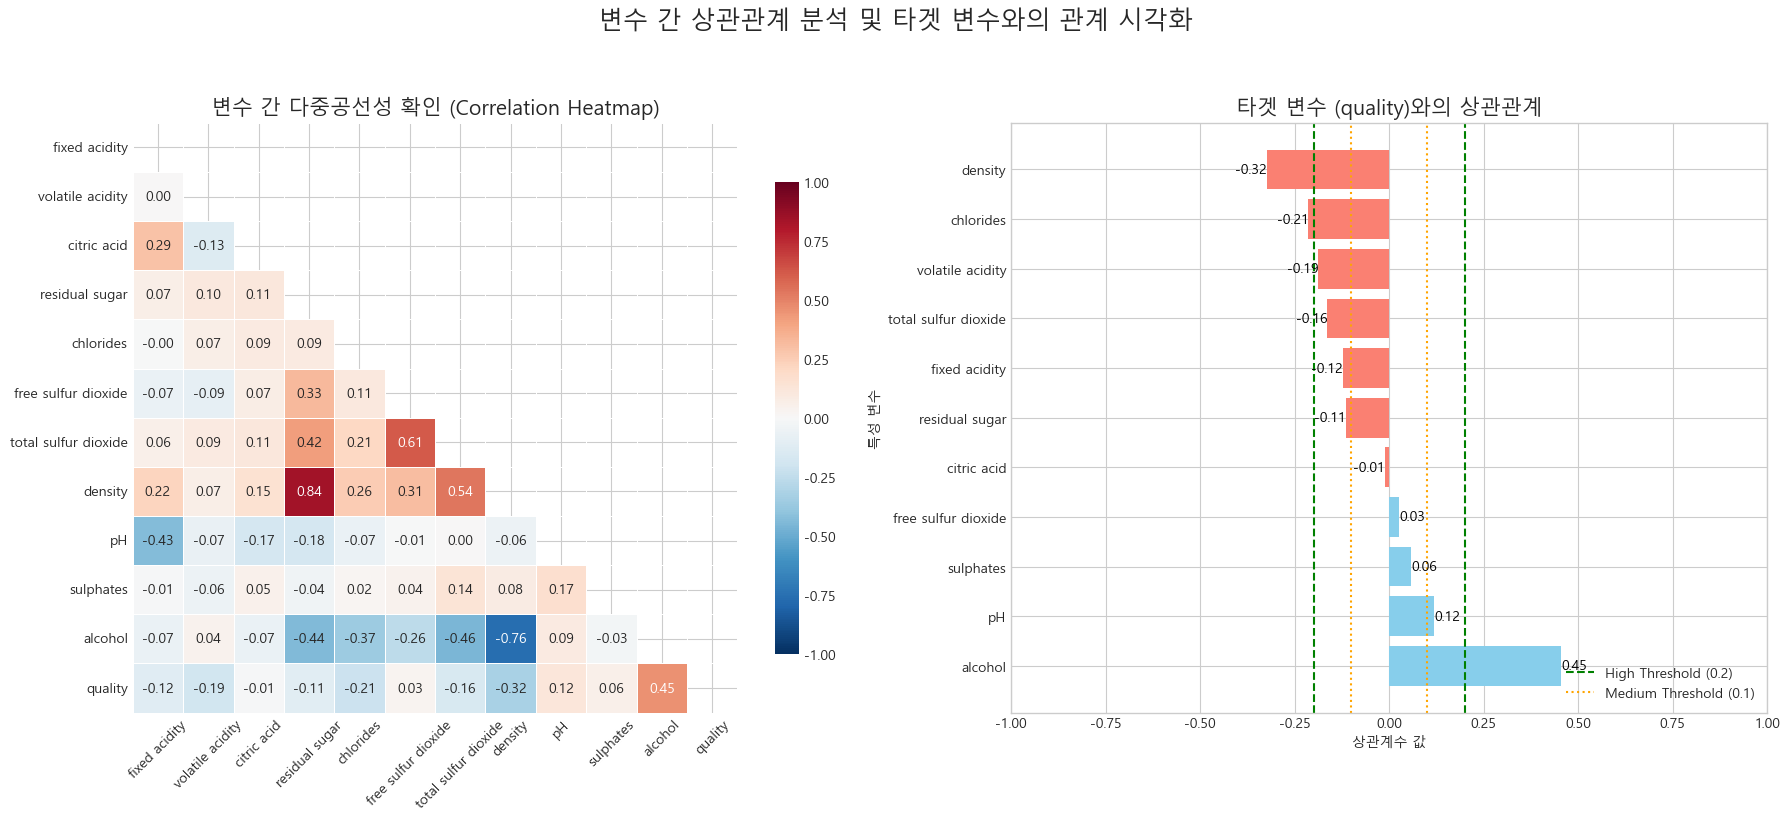


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.2): ['alcohol', 'chlorides', 'density']
Medium correlation features with quality (0.1 < |r| <= 0.2): ['pH', 'residual sugar', 'fixed acidity', 'total sulfur dioxide', 'volatile acidity']
Low correlation features with quality (<= 0.1): ['sulphates', 'free sulfur dioxide', 'citric acid']

선택된 상관관계 변수 목록 (High + Medium): ['alcohol', 'chlorides', 'density', 'pH', 'residual sugar', 'fixed acidity', 'total sulfur dioxide', 'volatile acidity']

최종 선택된 피처: ['alcohol', 'chlorides', 'density', 'pH', 'residual sugar', 'fixed acidity', 'total sulfur dioxide', 'volatile acidity']


In [25]:
# 함수 실행
selected_features = visualize_and_classify_correlation(X_train, y_train, 
                                                       target_name='quality', 
                                                       high_threshold=0.2, 
                                                       medium_threshold=0.1)

print("\n최종 선택된 피처:", selected_features)

### 분석: 히트맵을 통한 다중공선성 확인
- **강한 음의 상관관계**: `Alcohol`과 `Density` (-0.76). 밀도가 높으면 알코올 도수가 낮은 경향이 있습니다.
- **강한 양의 상관관계**: `Free Sulfur Dioxide`와 `Total Sulfur Dioxide` (0.61). 이는 화학적으로 당연한 귀결입니다. `residual sugar`와 `density` (0.84). 당분이 많으면 밀도가 높아집니다.
- **결론**: 상관관계가 너무 높은 변수 쌍(0.6 이상)이 존재한다면, 둘 중 하나를 제거하거나 두 변수를 결합하여 새로운 파생 변수를 만드는 것이 모델의 안정성을 높이는 데 도움이 됩니다.

In [33]:
def calculate_vif(df):
    """VIF 계산 함수 - 다중공선성 분석"""
    # 데이터프레임이 비어있거나 단일 열인 경우 처리
    if df.shape[1] == 0:
        return pd.DataFrame({'Features': [], 'VIF': []})
    
    vif = pd.DataFrame()
    vif["Features"] = df.columns
    
    # 단일 변수는 VIF가 정의되지 않거나 1.0
    if df.shape[1] == 1:
        vif["VIF"] = 1.0
    else:
        # variance_inflation_factor는 numpy 배열을 사용합니다.
        vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
        
    return vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)

def run_vif_analysis(X_data, vif_threshold=10):
    """
    독립 변수의 VIF를 계산하고 시각화하며, VIF 임계값 미만인 피처 목록을 반환합니다. 
    (스케일링 전 기준 분석)

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        vif_threshold (int): 다중공선성 판단 VIF 임계값. 기본값은 10.

    Returns:
        list: VIF 임계값 미만인 피처 목록.
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return []

    # 1. VIF 계산
    vif_results = calculate_vif(X_data)
    
    print(f"\nVIF 분석 결과 (VIF > {vif_threshold}: 다중공선성 의심):")
    print(vif_results)
    
    # 2. VIF 시각화
    plt.figure(figsize=(12, 6))
    
    # VIF 임계값 기준으로 색상 설정
    colors = ['red' if v > vif_threshold else 'green' for v in vif_results['VIF']]
    
    plt.barh(vif_results['Features'], vif_results['VIF'], color=colors)
    plt.axvline(x=vif_threshold, color='red', linestyle='--', label=f'VIF = {vif_threshold} (임계값)')
    
    plt.xlabel('VIF')
    plt.title('VIF (Variance Inflation Factor) - 다중공선성 분석', fontsize=15)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. VIF 기준 피처 선택
    vif_selected = vif_results[vif_results['VIF'] < vif_threshold]['Features'].tolist()
    
    print(f"\nVIF < {vif_threshold}인 피처 ({len(vif_selected)}개): {vif_selected}")
    
    return vif_selected


VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features          VIF
0                density  1048.172210
1                     pH   588.763161
2                alcohol   118.613334
3          fixed acidity    96.725253
4   total sulfur dioxide    24.365819
5              sulphates    20.856395
6            citric acid    10.070918
7       volatile acidity     9.749787
8    free sulfur dioxide     9.471915
9              chlorides     6.487322
10        residual sugar     3.808092


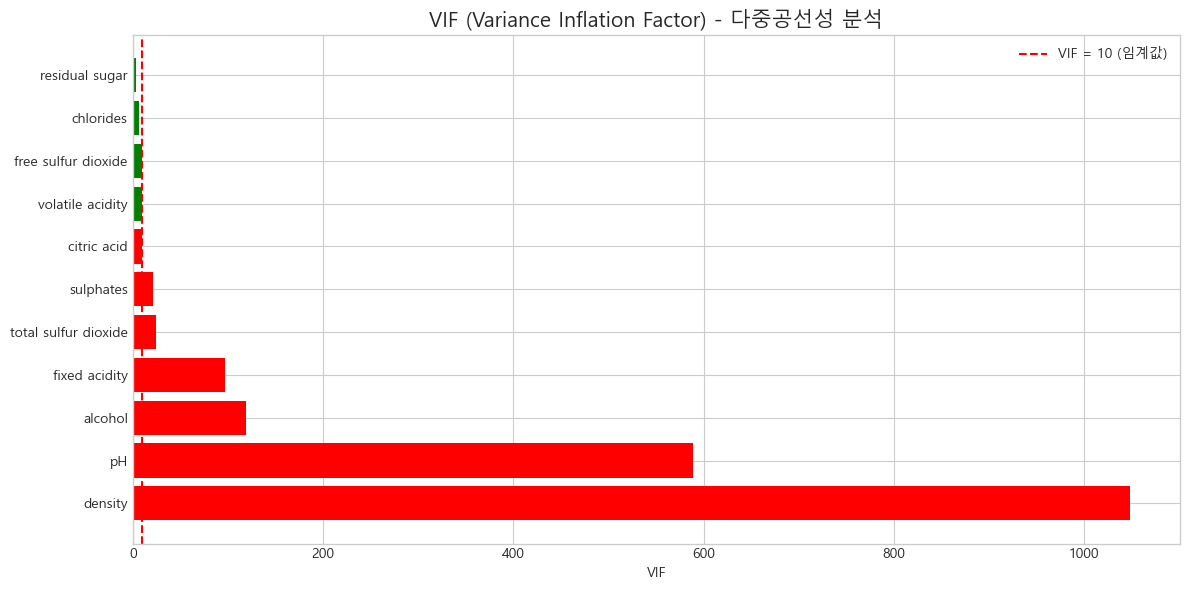


VIF < 10인 피처 (4개): ['volatile acidity', 'free sulfur dioxide', 'chlorides', 'residual sugar']


In [34]:
# 함수 실행
selected_vif_features = run_vif_analysis(X_train)

==================== 스케일링 후 VIF ====================

VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features        VIF
0                density  23.992248
1         residual sugar  11.357709
2                alcohol   6.551377
3          fixed acidity   2.521926
4   total sulfur dioxide   2.203564
5                     pH   2.144042
6    free sulfur dioxide   1.783719
7              chlorides   1.233250
8            citric acid   1.158688
9              sulphates   1.150175
10      volatile acidity   1.144587


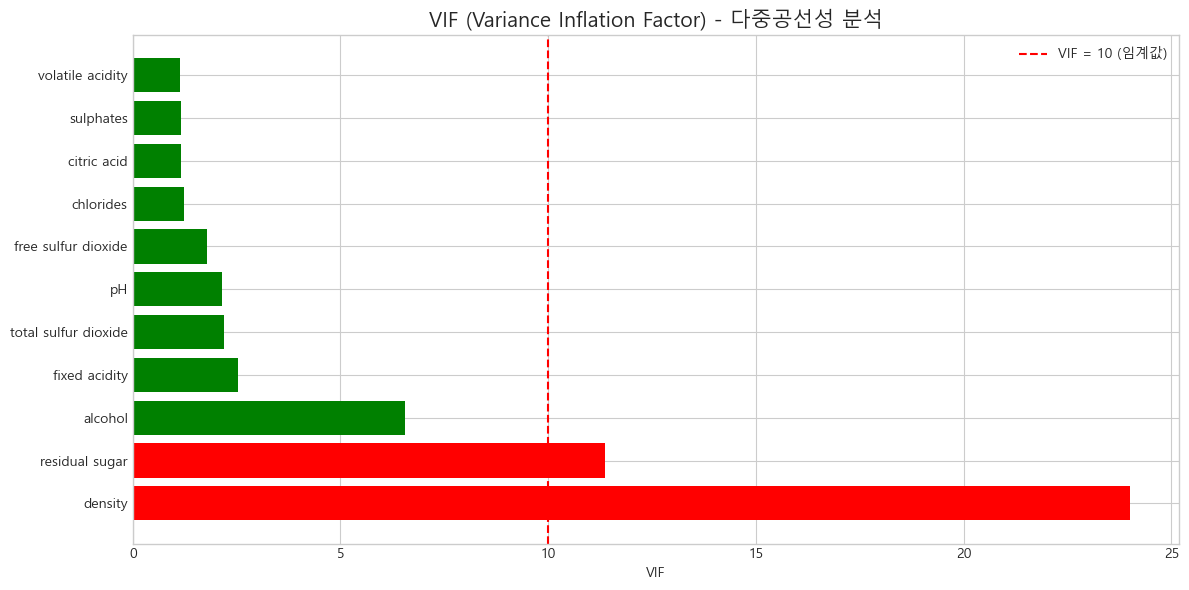


VIF < 10인 피처 (9개): ['alcohol', 'fixed acidity', 'total sulfur dioxide', 'pH', 'free sulfur dioxide', 'chlorides', 'citric acid', 'sulphates', 'volatile acidity']


In [36]:
# 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
print("=" * 20, "스케일링 후 VIF","=" * 20)
scaler_temp = StandardScaler()
X_scaled_temp = pd.DataFrame(
    scaler_temp.fit_transform(X_train),
    columns=X_train.columns
)

# 함수 실행
selected_vif_features = run_vif_analysis(X_scaled_temp)

### 분석: VIF 를 통한 다중공선성 확인
* 시각화 해석: 스케일링 전후 VIF에 큰 차이가 있었으며, 이는 데이터 스케일이 다중공선성에 미치는 영향을 보여줍니다. 스케일링 후에도 `density` 와 `residual sugar` 같은 일부 변수들은 여전히 높은 VIF를 보여 다중공선성이 강합니다. 
* 결론: 따라서 모델의 안정성을 위해 VIF가 10 이상인 `density` 및 `residual sugar` 변수를 **필터링**하는 것을 고려해야 합니다. 또한, **스케일링**이 다중공선성에 미치는 영향을 보여주므로, 스케일링을 적용하는 것이 모델의 안정성을 높이는 데 도움이 될 수 있습니다.
* 다중공선성: 여러 feature가 서로 너무 닮아서 모델이 어떤 변수가 실제로 영향을 주는지 구분하기 어려운 상태

In [37]:
# 상관관계와 VIF 를 통한 변수 선택
before_scale_features = list(set(selected_corr_features + selected_vif_features))
print(f"before_scale_features: {len(before_scale_features)}개 {before_scale_features}")

before_scale_features: 11개 ['free sulfur dioxide', 'volatile acidity', 'sulphates', 'chlorides', 'residual sugar', 'pH', 'citric acid', 'fixed acidity', 'alcohol', 'density', 'total sulfur dioxide']


## 3. 이상치(Outlier) 탐지 및 처리 전략 비교

데이터의 품질을 높이기 위해 이상치를 제거합니다. 여기서는 두 가지 방법을 시도하고 비교하여 최적의 방법을 선택합니다.

1.  **IQR (Interquartile Range) 방식**: 데이터의 25%~75% 범위를 기준으로 1.5배 벗어난 값을 제거. 직관적이나 데이터 손실이 클 수 있음.
2.  **Isolation Forest**: 머신러닝 기반의 이상치 탐지 기법. 고차원 데이터에서 효과적이며 데이터의 패턴을 고려함.

In [43]:
def detect_outliers_iqr(df, n=1.5):
    """
    IQR 방법을 사용하여 데이터프레임 내의 이상치를 탐지하고,
    이상치로 판단된 행의 위치 인덱스(positional index)를 반환합니다.
    
    Args:
        df (pd.DataFrame): 이상치를 탐지할 데이터프레임 (예: X_train).
        n (float): IQR 배수 (일반적으로 1.5).
        
    Returns:
        np.array: 이상치로 판단된 행의 위치 기반 인덱스 배열.
    """
    
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 범위: Q1 - n*IQR ~ Q3 + n*IQR
    lower_bound = Q1 - n * IQR
    upper_bound = Q3 + n * IQR
    
    print("=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===")
    outlier_info = pd.DataFrame({
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })
    print(outlier_info)

    # 1. 이상치 조건 (어떤 컬럼이라도 범위 밖에 있는 경우)
    outlier_condition = ((df < lower_bound) | (df > upper_bound)).any(axis=1)
    
    # 2. 이상치로 판단된 행의 위치 기반 인덱스를 찾기
    # np.where는 True인 값들의 인덱스를 튜플 형태로 반환합니다.
    # [0]을 사용하여 행 인덱스만 추출합니다.
    outlier_pos_indices = np.where(outlier_condition)[0]
    
    return outlier_pos_indices

In [44]:
# 4.2 Isolation Forest 방식
def detect_outliers_if(X):
    # contamination: 이상치 비율 예상치 (약 5%로 가정)
    clf = IsolationForest(max_samples='auto', random_state=SEED, contamination=0.05)
    preds = clf.fit_predict(X)
    return np.where(preds == -1)[0] # -1이 이상치


In [ ]:
# 실험 진행
outliers_iqr = detect_outliers_iqr(X_train)
outliers_if = detect_outliers_if(X_train)

print(f"\n총 데이터 개수: {len(X_train)}")
print(f"IQR 방식 (2개 이상 변수 이상치) 제거 대상 개수: {len(outliers_iqr)}")
print(f"Isolation Forest(IF) 방식 제거 대상 개수: {len(outliers_if)}")



# 최종 결정: Isolation Forest 적용 (다변량 관계 고려)
# 1. 마스크 생성 (모든 행을 True로 초기화)
# 단, Train 데이터에서만 제거해야 함!
mask = np.ones(len(X_train), dtype=bool)
# 2. 함수 호출 및 위치 인덱스를 사용하여 마스크 업데이트 (False로 설정)
mask[detect_outliers_iqr(X_train)] = False 

# 3. 이상치 제거된 데이터셋 생성
X_train_clean_iqr = X_train[mask]
y_train_clean_iqr = y_train[mask]

mask = np.ones(len(X_train), dtype=bool)
mask[detect_outliers_if(X_train)] = False # Isolation Forest 결과를 적용
X_train_clean_if = X_train[mask]
y_train_clean_if = y_train[mask]

# 결과 출력
print(f"IQR: 이상치 제거 후 Train Set 크기: {X_train_clean_iqr.shape} (삭제된 행: {len(X_train) - len(X_train_clean_iqr)})")
print(f"IQR: 제거 후 데이터 개수 (X_train_clean): {len(X_train_clean_iqr)}  제거 후 데이터 개수 (y_train_clean): {len(y_train_clean_iqr)}")

print(f"IF: 이상치 제거 후 Train Set 크기: {X_train_clean_if.shape} (삭제된 행: {len(X_train) - len(X_train_clean_if)})")
print(f"IF: 제거 후 데이터 개수 (X_train_clean): {len(X_train_clean_if)}  제거 후 데이터 개수 (y_train_clean): {len(y_train_clean_if)}")

=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar         -10.300000    21.700000
chlorides                0.015000     0.071000
free sulfur dioxide    -13.000000    83.000000
total sulfur dioxide    17.500000   261.500000
density                  0.985299     1.002869
pH                       2.790000     3.590000
sulphates                0.200000     0.760000
alcohol                  6.550000    14.150000

총 데이터 개수: 3200
IQR 방식 (2개 이상 변수 이상치) 제거 대상 개수: 564
Isolation Forest(IF) 방식 제거 대상 개수: 160
=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar         -10.300000    21.700000
chlorides      

1. 💡 PCA란 무엇인가? (What is PCA?)
* 차원 축소 기법: 데이터가 가진 정보 손실을 최소화하면서 고차원 데이터를 저차원(주로 2~3차원)으로 축소하는 데 사용되는 통계적 방법입니다.

* 주요 변동성 포착: 데이터의 **분산(변동성)**을 가장 잘 설명하는 새로운 축, 즉 **주성분(Principal Components)**을 찾아 데이터를 재구성합니다.

* 데이터 요약: 데이터를 가장 잘 나타내는 **핵심적인 특징(Feature)**들을 추출하여 복잡성을 줄이고 분석을 용이하게 합니다.

2. 🎯 PCA를 사용하는 이유 (Why Use PCA?)
* 다차원 시각화: 다차원 데이터의 이상치 위치를 2차원 평면에 투영하여 IQR과 Isolation Forest의 탐지 결과를 한눈에 비교할 수 있게 합니다.

* 구조적 비교: 데이터의 **분산과 주요 구조(군집)**를 최대한 보존하면서, 이상치들이 군집에서 얼마나 멀리 떨어져 있는지 시각적으로 판단할 수 있게 합니다.

* 다변량 이상치 확인: Isolation Forest가 탐지한 다변량 이상치가 실제로 군집에서 고립되어 있는지를 가장 효과적으로 보여줍니다.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# --- 새로운 함수 추가: 두 방법 비교 시각화 ---
def compare_outliers_scatter(X_data, detect_iqr_func, detect_if_func, title="IQR vs Isolation Forest 이상치 비교 (PCA)"):
    """
    PCA를 사용하여 데이터 차원을 2D로 축소하고, IQR과 Isolation Forest로 탐지된
    이상치를 산점도로 시각적으로 비교하는 함수입니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        detect_iqr_func (function): IQR 이상치를 탐지하고 위치 인덱스를 반환하는 함수.
        detect_if_func (function): Isolation Forest 이상치를 탐지하고 위치 인덱스를 반환하는 함수.
        title (str): 그래프의 제목.
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return

    # 1. 데이터 전처리 및 PCA 수행
    
    # PCA는 스케일에 민감하므로 StandardScaler를 사용하여 데이터를 표준화합니다.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    
    # PCA를 사용하여 2개의 주성분으로 축소
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    
    # 2. 두 가지 방법으로 이상치 탐지 및 마스킹
    
    # 탐지 함수 호출 (위치 인덱스를 반환)
    outliers_iqr_pos = detect_iqr_func(X_data)
    outliers_if_pos = detect_if_func(X_data)
    
    # 불리언 마스크 생성
    is_iqr_outlier = np.zeros(len(X_data), dtype=bool)
    is_if_outlier = np.zeros(len(X_data), dtype=bool)
    
    is_iqr_outlier[outliers_iqr_pos] = True
    is_if_outlier[outliers_if_pos] = True
    
    # 3. 데이터 포인트 분류
    # 0: 정상 (Normal), 1: IQR만 이상치, 2: IF만 이상치, 3: 둘 다 이상치
    outlier_type = np.zeros(len(X_data), dtype=int)
    
    outlier_type[(is_iqr_outlier) & (is_if_outlier)] = 3      # 3: 둘 다 이상치
    outlier_type[(is_iqr_outlier) & (~is_if_outlier)] = 1     # 1: IQR만 이상치
    outlier_type[(~is_iqr_outlier) & (is_if_outlier)] = 2     # 2: IF만 이상치
    
    X_pca_df['Outlier_Type'] = outlier_type
    
    # 4. 시각화 
    
    plt.figure(figsize=(10, 8))
    
    # 색상, 마커, 레이블 설정
    colors = {0: 'blue', 1: 'red', 2: 'green', 3: 'black'}
    markers = {0: 'o', 1: 'X', 2: 's', 3: '*'}
    labels = {
        0: '정상 데이터 (Normal)',
        1: 'IQR만 이상치 (단변량)',
        2: 'IF만 이상치 (다변량)',
        3: '둘 다 이상치 (Both)'
    }

    # 데이터 분류별 산점도 그리기
    for type_val, group in X_pca_df.groupby('Outlier_Type'):
        plt.scatter(group['PC1'], group['PC2'], 
                    c=colors[type_val], 
                    marker=markers[type_val], 
                    label=labels[type_val],
                    s=type_val * 40 + 50, # 이상치일수록 마커 크기 키움
                    alpha=0.6)

    plt.title(title, fontsize=15)
    plt.xlabel(f'주성분 1 (PC1, 설명 분산: {pca.explained_variance_ratio_[0]:.2f})')
    plt.ylabel(f'주성분 2 (PC2, 설명 분산: {pca.explained_variance_ratio_[1]:.2f})')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar         -10.300000    21.700000
chlorides                0.015000     0.071000
free sulfur dioxide    -13.000000    83.000000
total sulfur dioxide    17.500000   261.500000
density                  0.985299     1.002869
pH                       2.790000     3.590000
sulphates                0.200000     0.760000
alcohol                  6.550000    14.150000


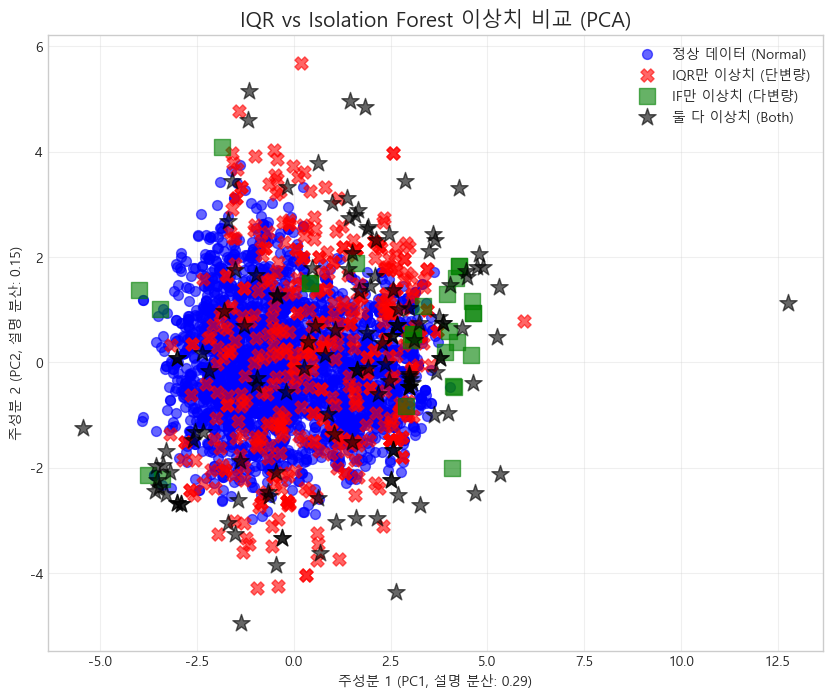

In [49]:
# 함수 실행:
compare_outliers_scatter(X_train, detect_outliers_iqr, detect_outliers_if)

1. 🔍 해석 (Interpretation)
IQR(빨간색 X)은 중앙 군집 주변까지 광범위하게 분포하며, Isolation Forest(초록색 ■)는 주로 군집 외곽에 고립되어 나타납니다. 둘 다 이상치(검은색 별)는 가장 극단적인 위치에 존재합니다.

2. 📝 분석 (Analysis)
IQR은 단변량 기준으로 과도하게 많은 데이터를 제거할 위험이 있으며, IF는 다변량 고립성을 기반으로 더 의미 있는 이상치를 선택적으로 탐지하는 데 효율적입니다.

3. ✅ 결론 (Conclusion)
Isolation Forest가 데이터의 구조를 보존하며 이상치를 제거하는 데 더 적합할 가능성이 높습니다. 최종 선택은 두 방법으로 데이터를 처리한 후 실제 모델 성능 지표를 비교하여 결정해야 합니다.

In [51]:
clf = IsolationForest(max_samples='auto', random_state=SEED, contamination=0.05)
preds = clf.fit_predict(X_train)
mask = preds != -1
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

print(f"이상치 제거 전: {len(X_train)} -> 제거 후: {len(X_train_clean)}")

이상치 제거 전: 3200 -> 제거 후: 3040


이상치 제거 전후 데이터 분포 비교

[1] 히스토그램 비교 (전/후 오버레이)


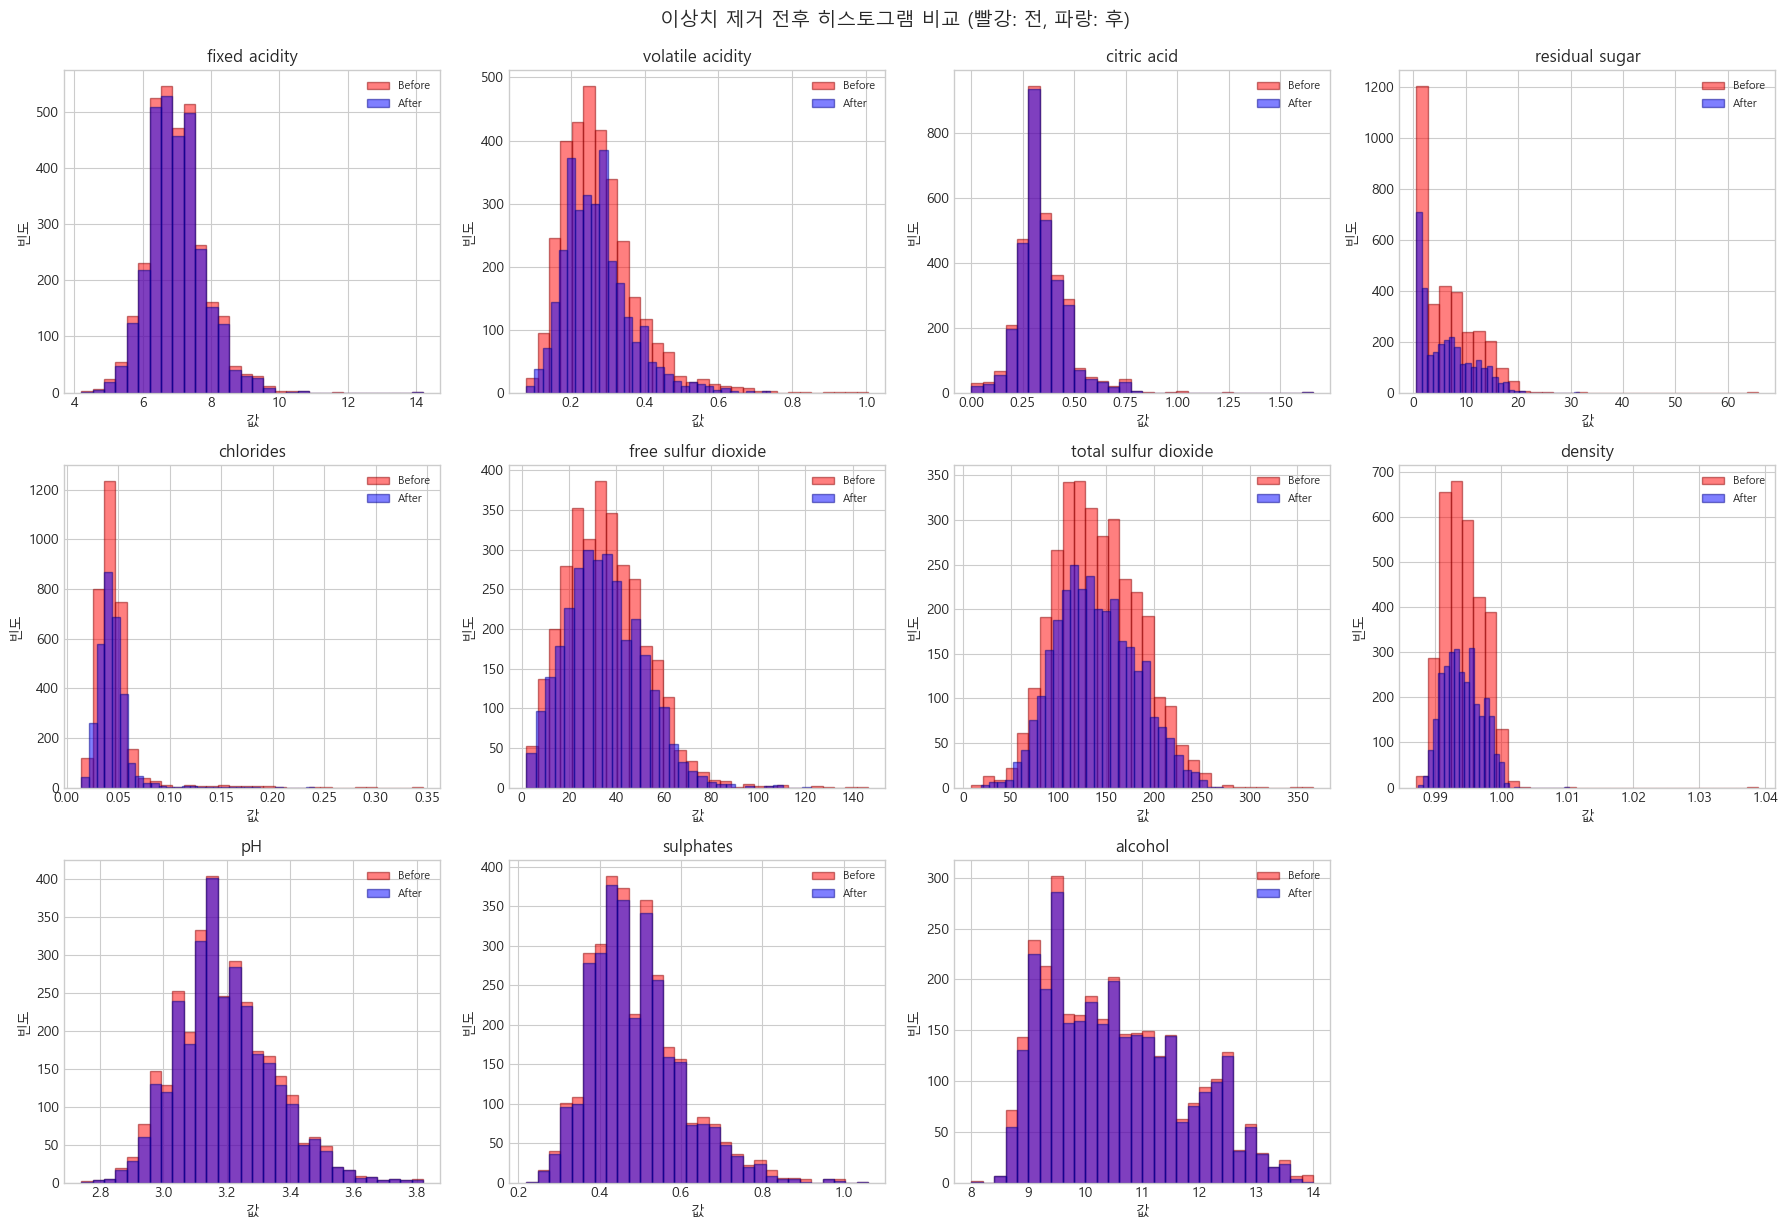


[2] 박스플롯 비교 (전/후)


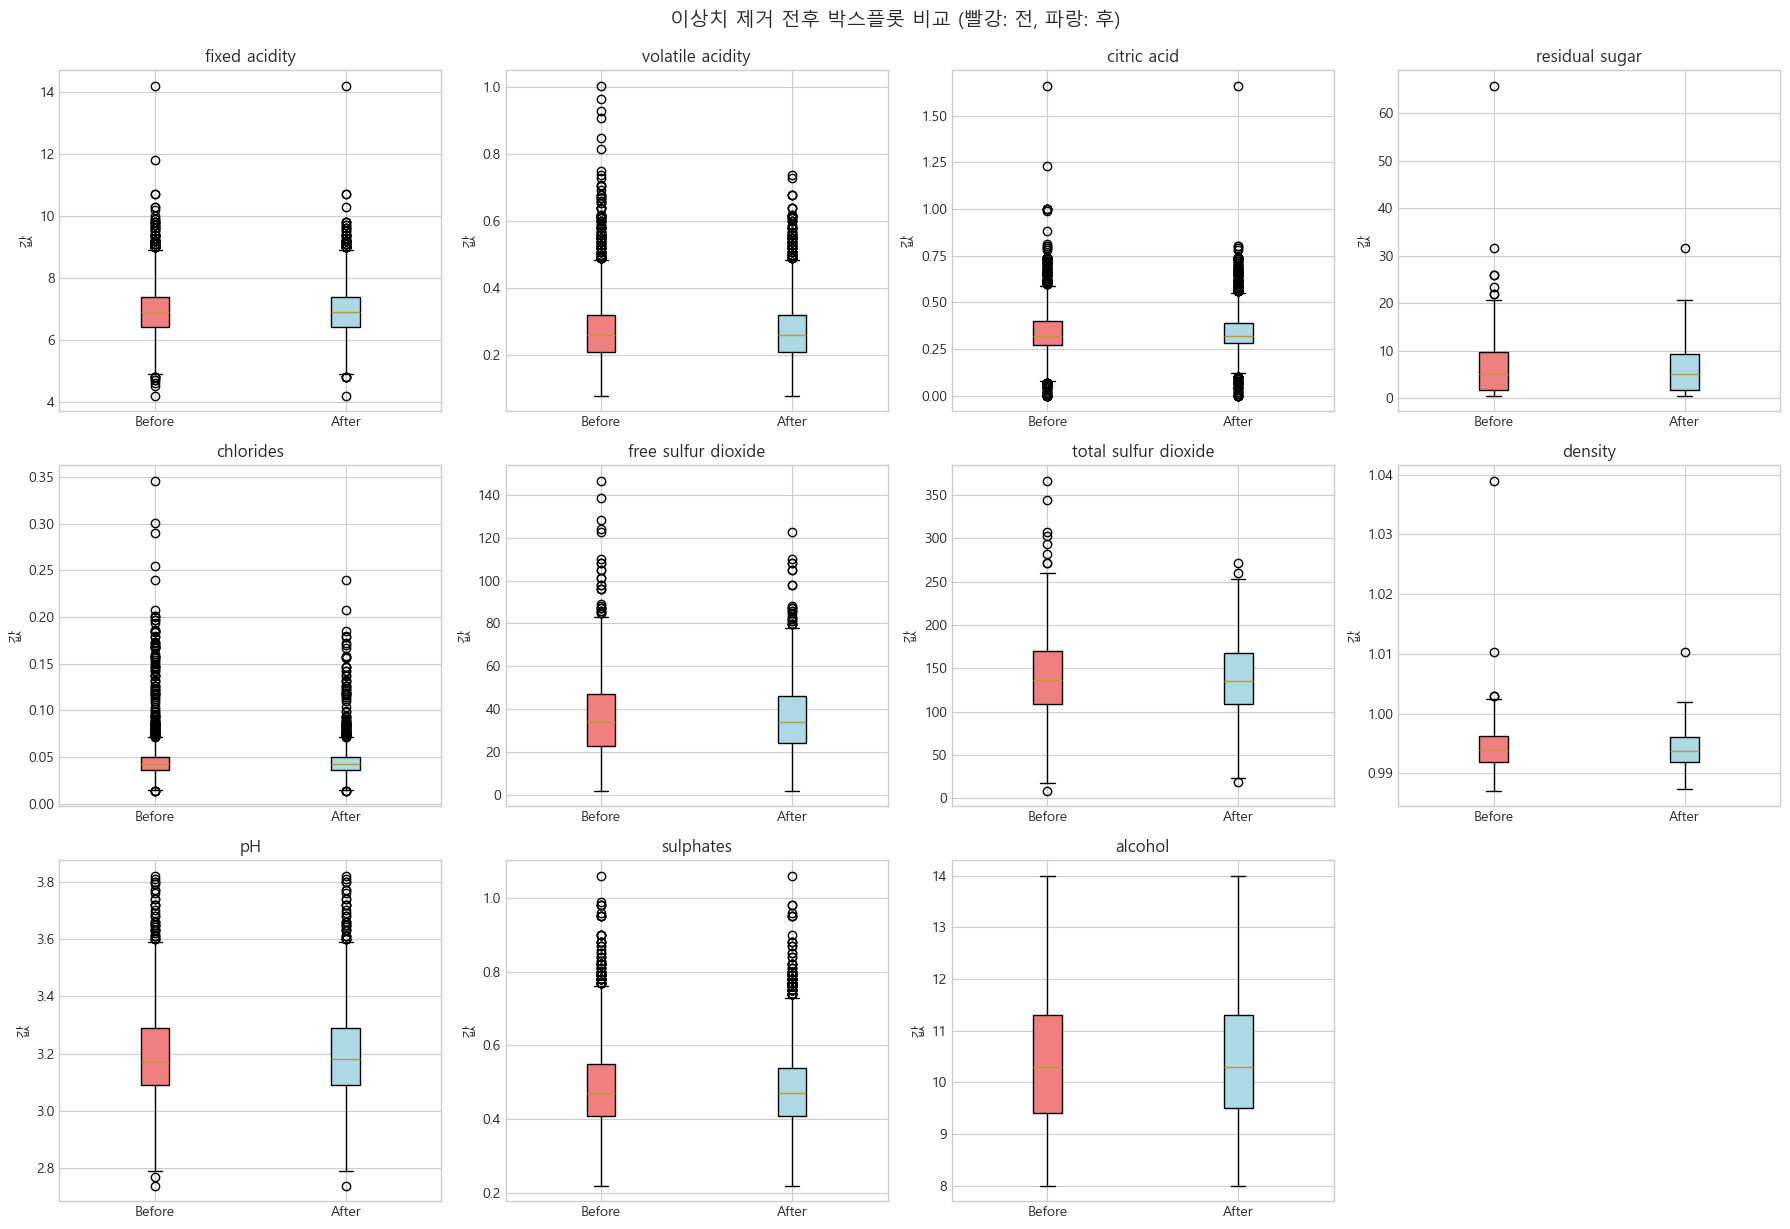


[3] 통계 요약 비교

데이터 건수 변화: 3200 → 3040 (제거: 160개, 5.00%)

=== 이상치 제거 전후 통계량 비교 ===
             Feature  Before_Mean  After_Mean  Mean_Diff  Before_Std  After_Std  Std_Diff
       fixed acidity       6.9740      6.9666    -0.0075      0.8421     0.8046   -0.0374
    volatile acidity       0.2760      0.2706    -0.0054      0.0998     0.0897   -0.0100
         citric acid       0.3422      0.3397    -0.0024      0.1232     0.1135   -0.0097
      residual sugar       6.3495      6.2160    -0.1335      5.1015     4.8175   -0.2840
           chlorides       0.0456      0.0441    -0.0015      0.0218     0.0160   -0.0057
 free sulfur dioxide      35.5827     35.2988    -0.2838     16.8608    16.0568   -0.8040
total sulfur dioxide     140.5647    139.4446    -1.1201     43.4816    41.4102   -2.0714
             density       0.9942      0.9941    -0.0001      0.0030     0.0028   -0.0002
                  pH       3.1916      3.1934     0.0018      0.1546     0.1517   -0.0029
           sulphat

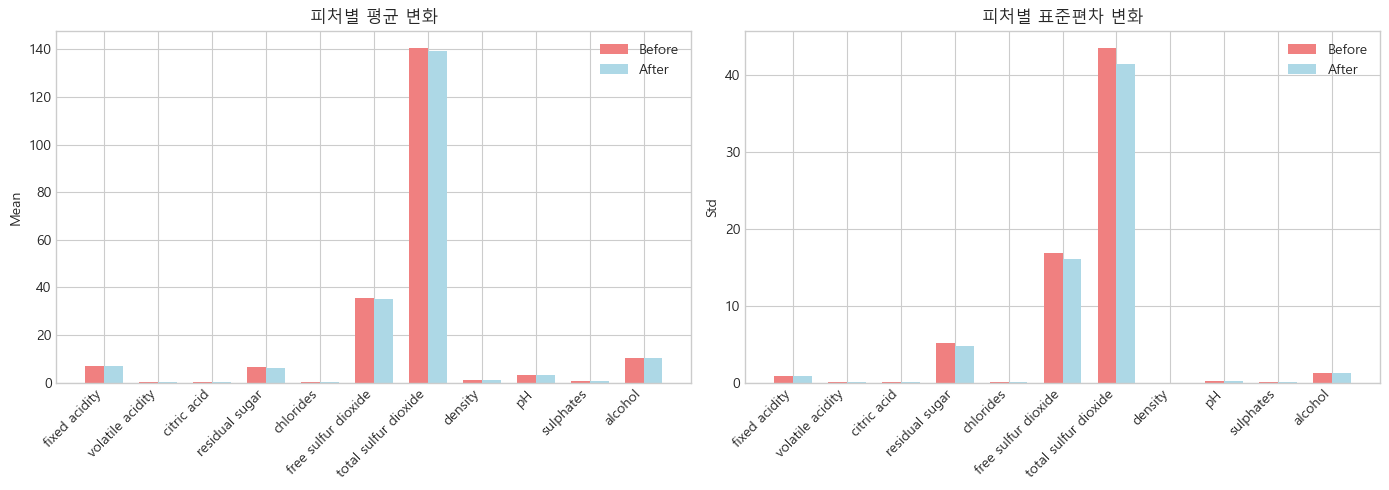


이상치 제거로 인해 극단값이 제거되어 분포가 더 집중되었습니다.


In [52]:
# ============================================
# 이상치 제거 전후 데이터 분포 비교
# ============================================
print("=" * 60)
print("이상치 제거 전후 데이터 분포 비교")
print("=" * 60)

# 1. 히스토그램 비교 (Histogram Overlay)
print("\n[1] 히스토그램 비교 (전/후 오버레이)")
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
    ax = axes[idx]
    # 전: X_train (이상치 제거 전)
    ax.hist(X_train[col], bins=30, alpha=0.5, label='Before', color='red', edgecolor='darkred')
    # 후: X_train_clean (이상치 제거 후)
    ax.hist(X_train_clean[col], bins=30, alpha=0.5, label='After', color='blue', edgecolor='darkblue')
    ax.set_title(f'{col}')
    ax.set_xlabel('값')
    ax.set_ylabel('빈도')
    ax.legend(loc='upper right', fontsize=8)

# 빈 subplot 제거
if len(X_train.columns) < len(axes):
    for idx in range(len(X_train.columns), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('이상치 제거 전후 히스토그램 비교 (빨강: 전, 파랑: 후)', y=1.02, fontsize=14)
plt.show()

# 2. 박스플롯 비교 (Before/After Box Plot)
print("\n[2] 박스플롯 비교 (전/후)")
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
    ax = axes[idx]
    # 전/후 데이터 준비
    data_before = X_train[col].values
    data_after = X_train_clean[col].values
    
    # 박스플롯 생성
    bp = ax.boxplot([data_before, data_after], labels=['Before', 'After'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightblue')
    ax.set_title(f'{col}')
    ax.set_ylabel('값')

# 빈 subplot 제거
if len(X_train.columns) < len(axes):
    for idx in range(len(X_train.columns), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('이상치 제거 전후 박스플롯 비교 (빨강: 전, 파랑: 후)', y=1.02, fontsize=14)
plt.show()

# 3. 통계 요약 테이블 (Statistical Summary)
print("\n[3] 통계 요약 비교")
print(f"\n데이터 건수 변화: {len(X_train)} → {len(X_train_clean)} (제거: {len(X_train) - len(X_train_clean)}개, {(len(X_train) - len(X_train_clean))/len(X_train)*100:.2f}%)")

# 전후 통계량 비교 테이블
stats_comparison = []
for col in X_train.columns:
    before_stats = X_train[col].describe()
    after_stats = X_train_clean[col].describe()
    
    stats_comparison.append({
        'Feature': col,
        'Before_Mean': before_stats['mean'],
        'After_Mean': after_stats['mean'],
        'Mean_Diff': after_stats['mean'] - before_stats['mean'],
        'Before_Std': before_stats['std'],
        'After_Std': after_stats['std'],
        'Std_Diff': after_stats['std'] - before_stats['std'],
        'Before_Min': before_stats['min'],
        'After_Min': after_stats['min'],
        'Before_Max': before_stats['max'],
        'After_Max': after_stats['max']
    })

stats_df = pd.DataFrame(stats_comparison)
print("\n=== 이상치 제거 전후 통계량 비교 ===")
print(stats_df[['Feature', 'Before_Mean', 'After_Mean', 'Mean_Diff', 'Before_Std', 'After_Std', 'Std_Diff']].round(4).to_string(index=False))

print("\n=== 이상치 제거 전후 범위(Min/Max) 비교 ===")
print(stats_df[['Feature', 'Before_Min', 'After_Min', 'Before_Max', 'After_Max']].round(4).to_string(index=False))

# 4. 분포 변화 요약 시각화
print("\n[4] 평균/표준편차 변화 시각화")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 변화
ax1 = axes[0]
x = np.arange(len(stats_df))
width = 0.35
bars1 = ax1.bar(x - width/2, stats_df['Before_Mean'], width, label='Before', color='lightcoral')
bars2 = ax1.bar(x + width/2, stats_df['After_Mean'], width, label='After', color='lightblue')
ax1.set_xticks(x)
ax1.set_xticklabels(stats_df['Feature'], rotation=45, ha='right')
ax1.set_ylabel('Mean')
ax1.set_title('피처별 평균 변화')
ax1.legend()

# 표준편차 변화
ax2 = axes[1]
bars1 = ax2.bar(x - width/2, stats_df['Before_Std'], width, label='Before', color='lightcoral')
bars2 = ax2.bar(x + width/2, stats_df['After_Std'], width, label='After', color='lightblue')
ax2.set_xticks(x)
ax2.set_xticklabels(stats_df['Feature'], rotation=45, ha='right')
ax2.set_ylabel('Std')
ax2.set_title('피처별 표준편차 변화')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n이상치 제거로 인해 극단값이 제거되어 분포가 더 집중되었습니다.")


### 분석: 이상치 제거 효과
- **시각화 해석**: 위 Violin Plot을 보면, `total sulfur dioxide`의 경우 제거 전에는 위쪽으로 아주 긴 꼬리(극단값)가 존재했으나, 제거 후에는 분포가 훨씬 안정적이고 정규분포에 가까운 형태로 변했습니다.
- **결론**: 이상치 제거는 모델이 극단적인 값에 휘둘리지 않고 일반적인 패턴을 학습하는 데 도움을 줍니다. Isolation Forest는 다변량 관계를 고려하여 이러한 포인트들을 효과적으로 제거했습니다.

## 이상치 제거 후 상관관계/VIF 분석

In [65]:
# 데이터 전처리를 확인
# 피처별 Quality 구분 능력 분석 (Boxplot)
# 수치형 변수들의 분포 (Histogram & KDE)
# 상관관계 확인
# VIF 분석
# 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
def check_data(X_data, y_data):
    """
    데이터 전처리를 확인합니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
    """
    # 피처별 Quality 구분 능력 분석 (Boxplot)
    plot_feature_quality_boxplots(X_data, y_data)
    # 수치형 변수들의 분포 (Histogram & KDE)
    plot_numerical_distribution(X_data)
    # 상관관계 확인
    selected_features = visualize_and_classify_correlation(X_data, y_data, 
                                                        target_name='quality', 
                                                        high_threshold=0.2, 
                                                        medium_threshold=0.1)
    # VIF 분석
    selected_vif_features = run_vif_analysis(X_data)
    # 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
    print("=" * 20, "스케일링 후 VIF","=" * 20)
    scaler_temp = StandardScaler()
    X_scaled_temp = pd.DataFrame(
        scaler_temp.fit_transform(X_data),
        columns=X_data.columns
    )

    # 함수 실행
    selected_vif_features = run_vif_analysis(X_scaled_temp)
    # 상관관계와 VIF 를 통한 변수 선택
    before_scale_features = list(set(selected_corr_features + selected_vif_features))
    print(f"before_scale_features: {len(before_scale_features)}개 {before_scale_features}")

총 11개의 피처에 대해 Quality별 Boxplot을 생성합니다.


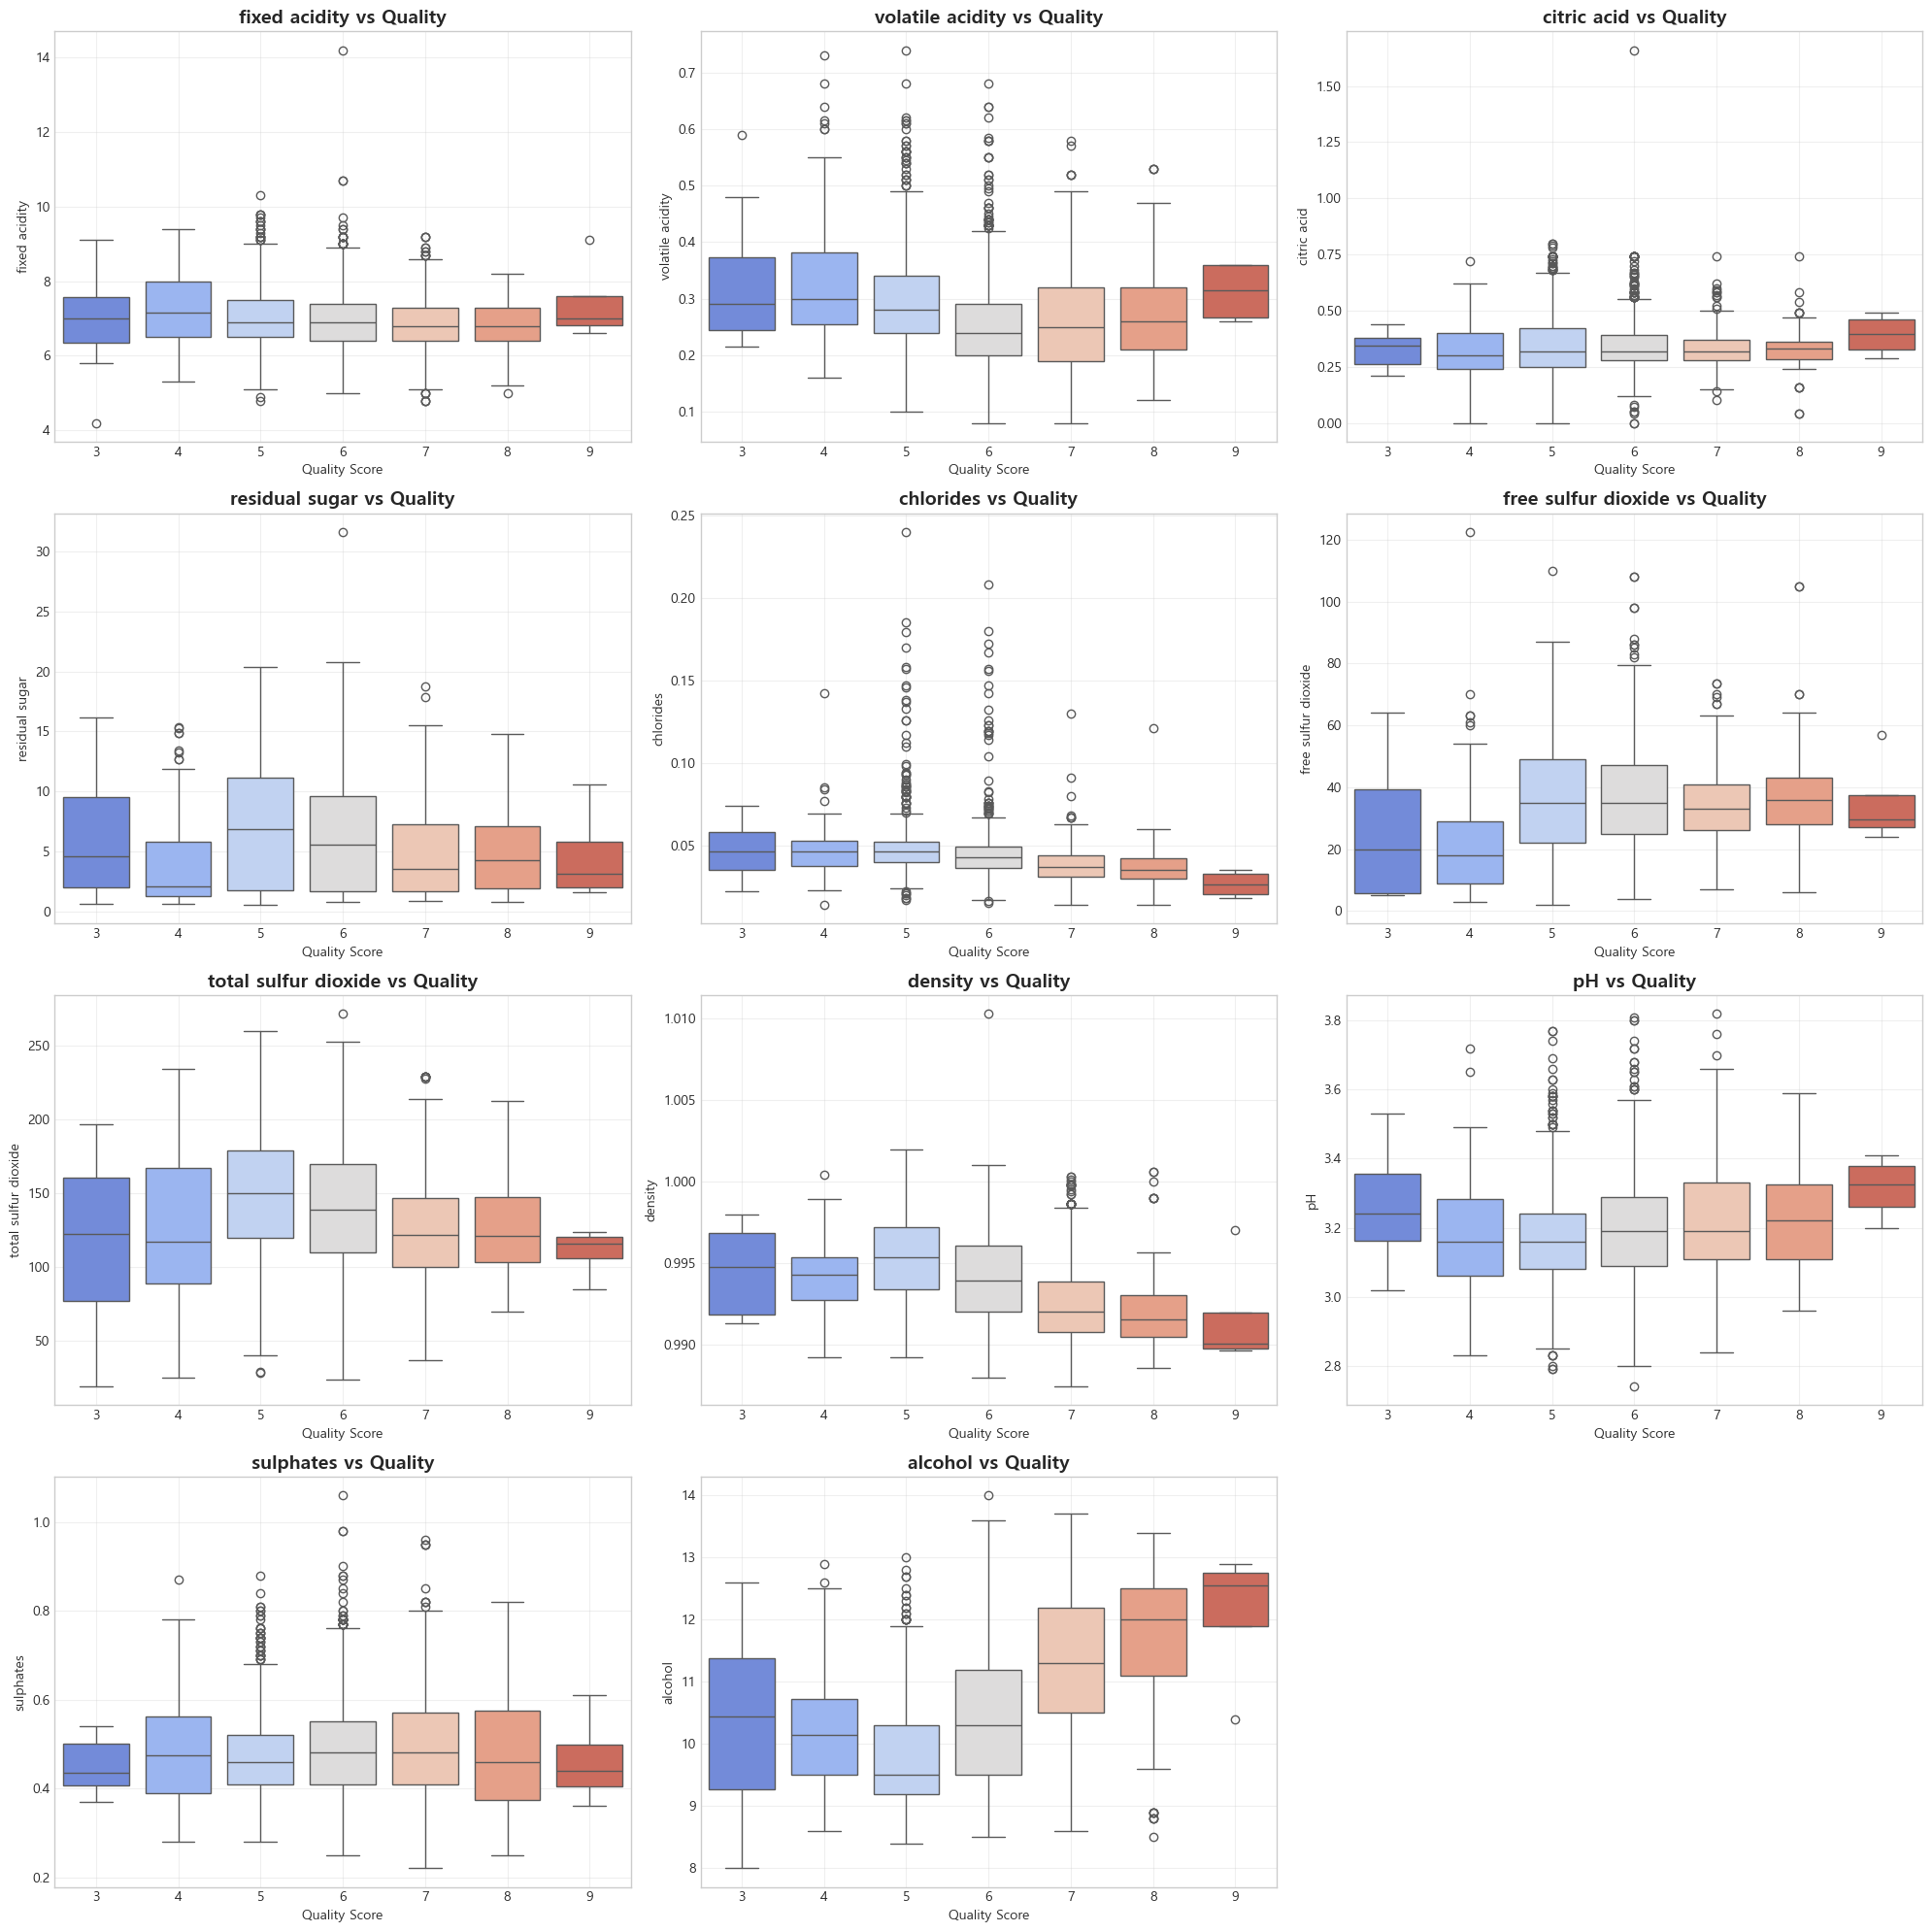

총 11개의 수치형 피처 분포를 생성합니다.


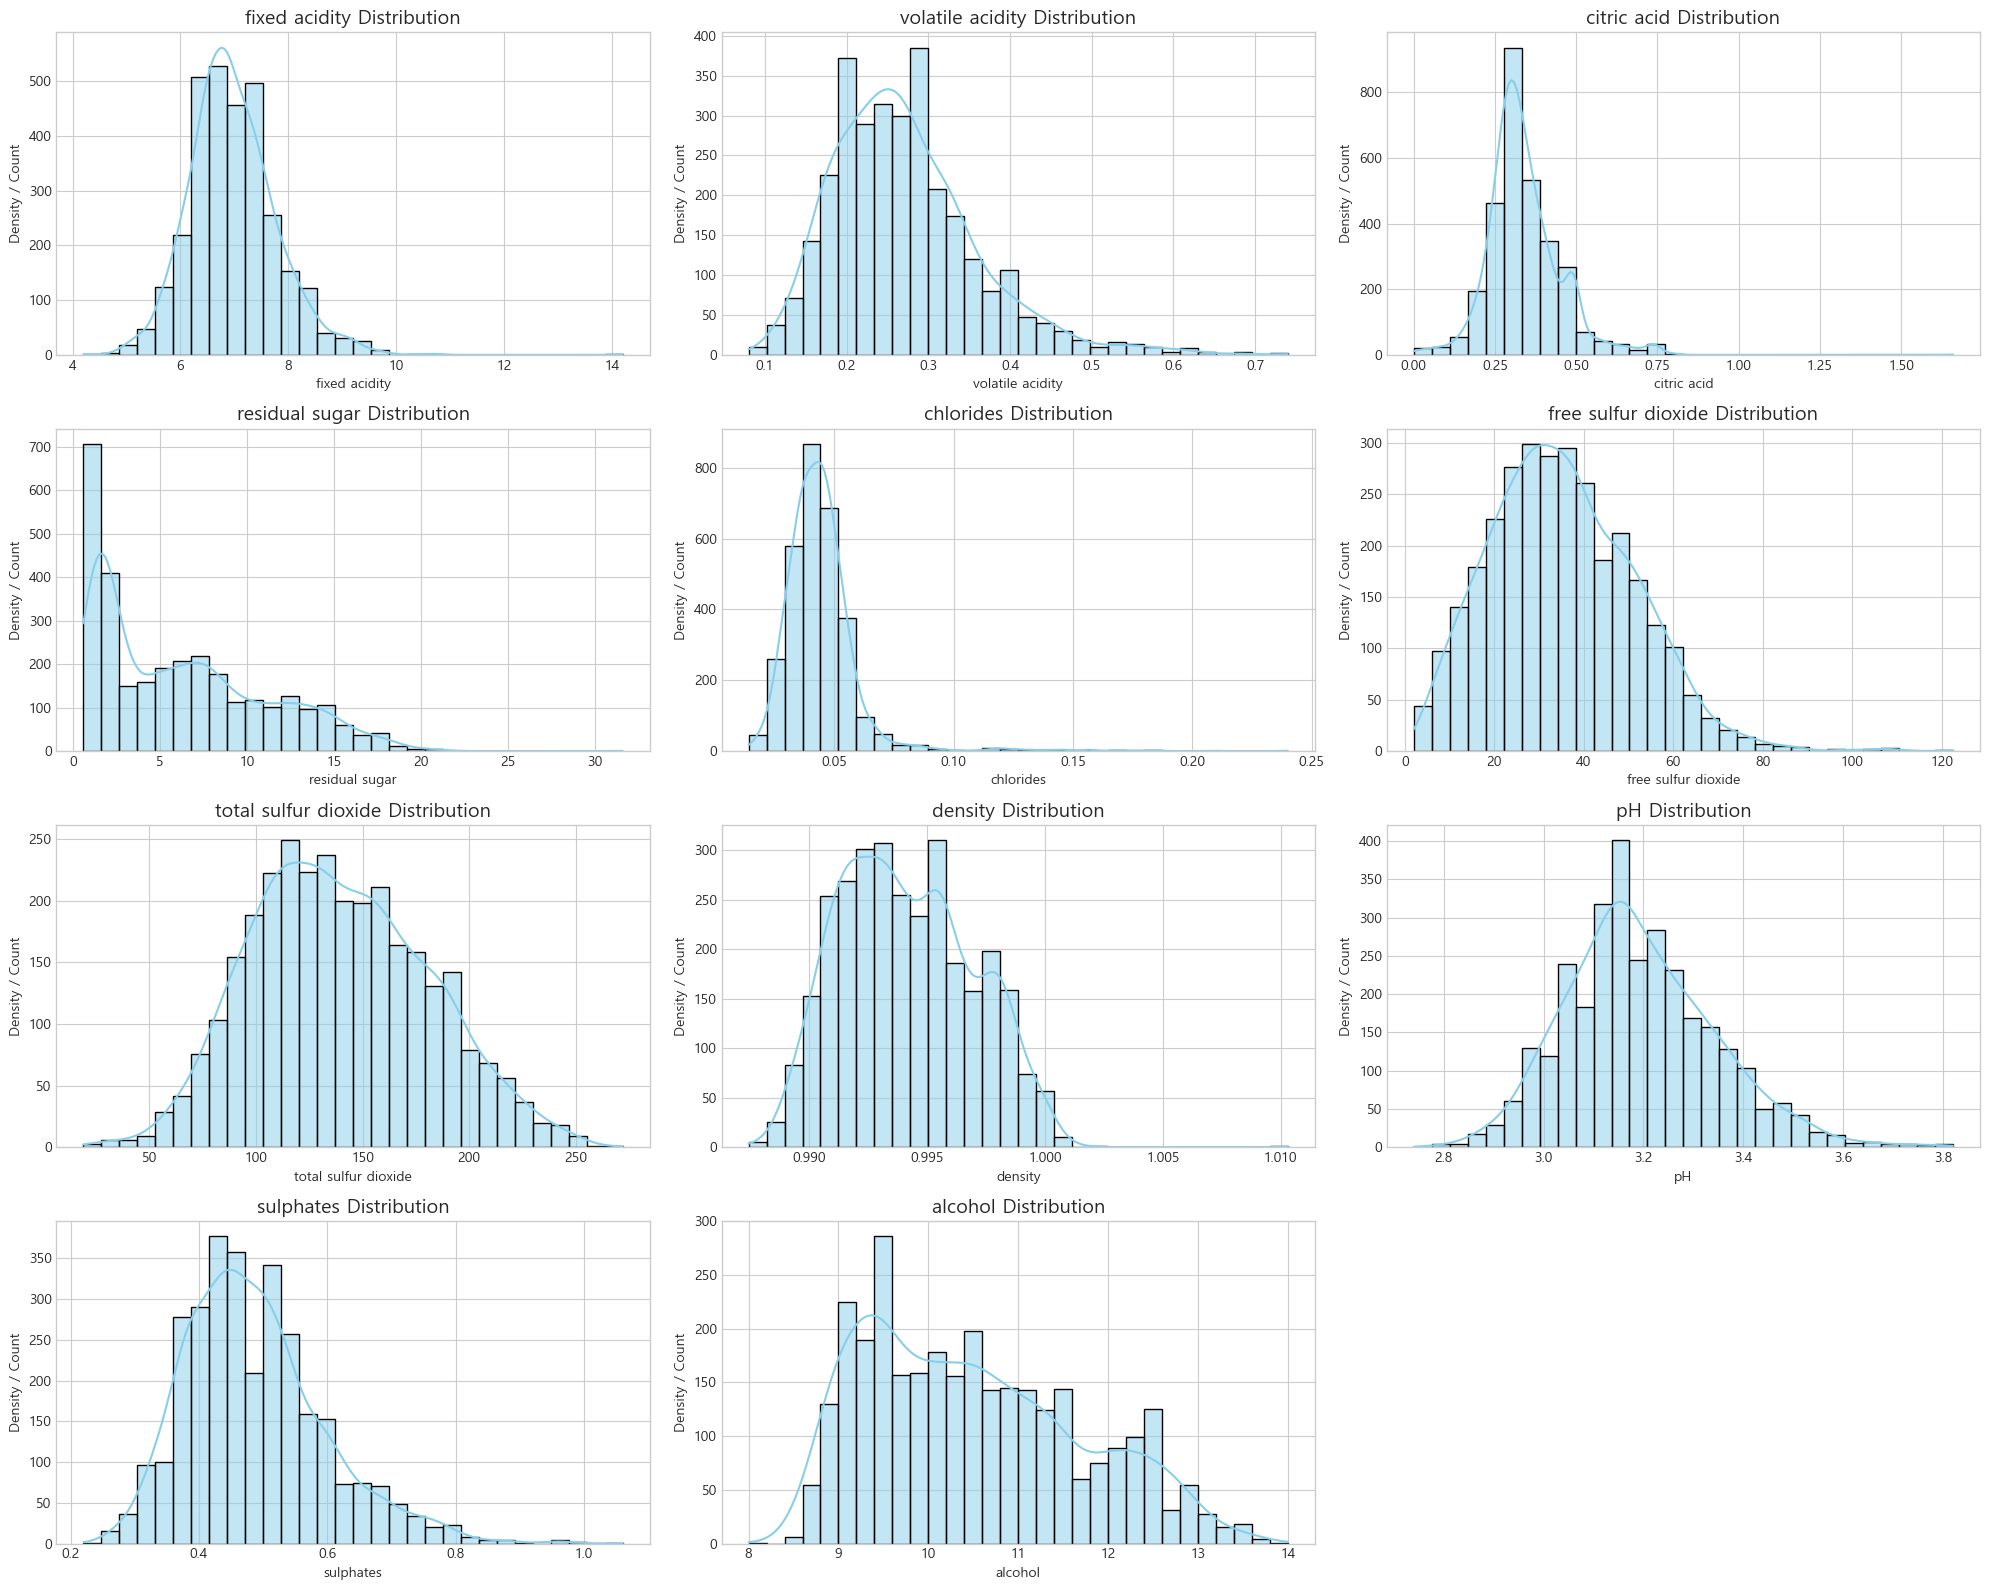

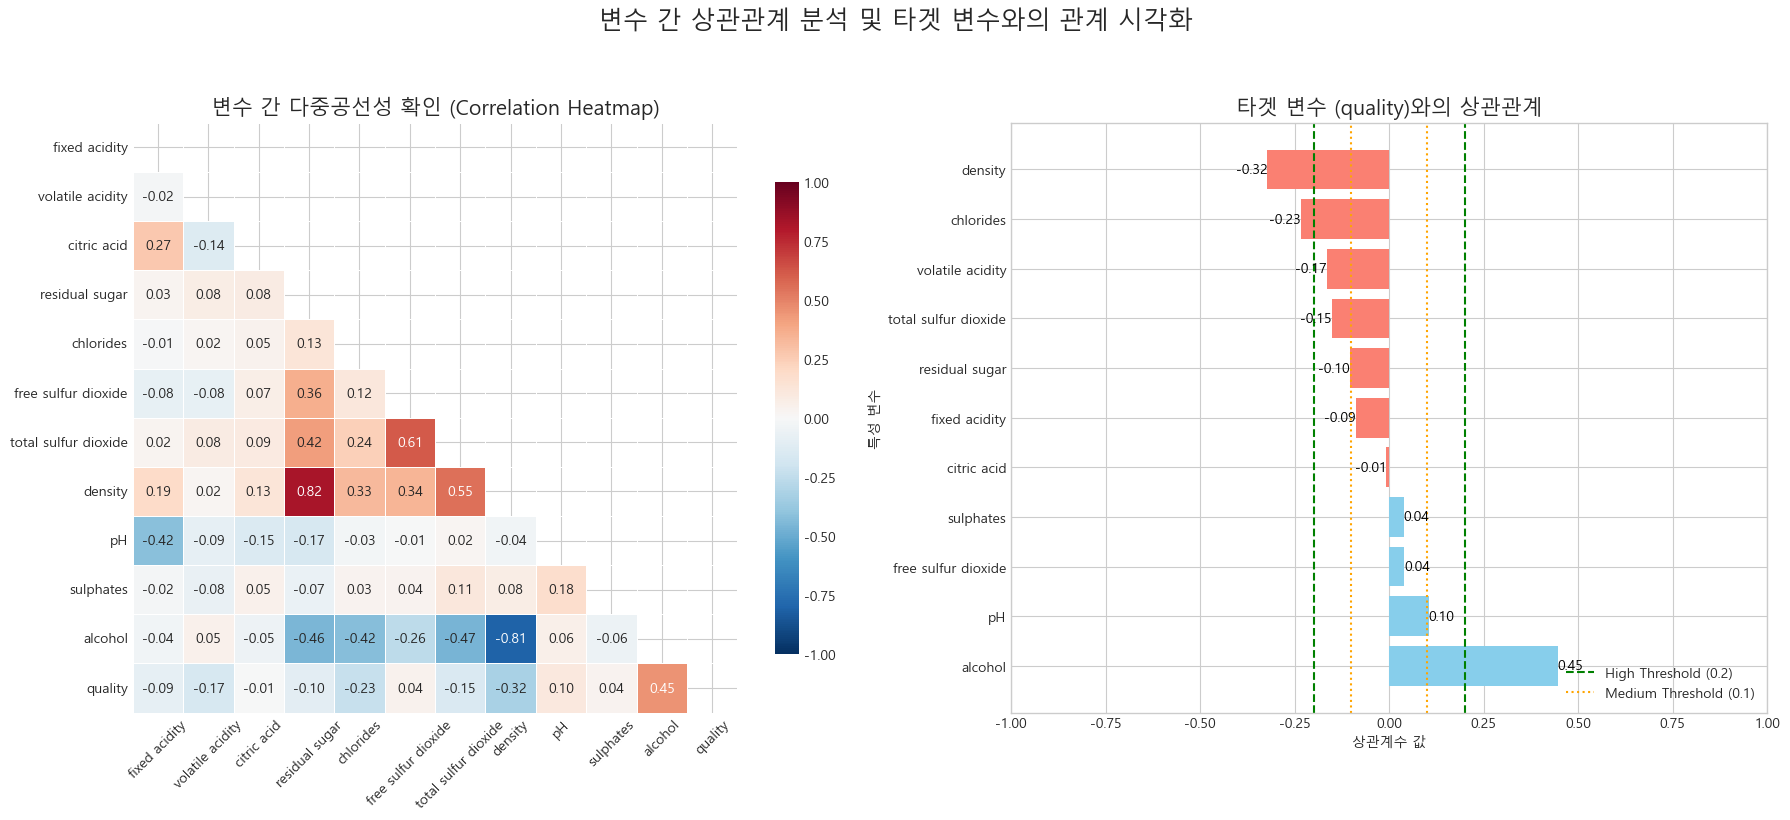


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.2): ['alcohol', 'chlorides', 'density']
Medium correlation features with quality (0.1 < |r| <= 0.2): ['pH', 'residual sugar', 'total sulfur dioxide', 'volatile acidity']
Low correlation features with quality (<= 0.1): ['free sulfur dioxide', 'sulphates', 'citric acid', 'fixed acidity']

선택된 상관관계 변수 목록 (High + Medium): ['alcohol', 'chlorides', 'density', 'pH', 'residual sugar', 'total sulfur dioxide', 'volatile acidity']

VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features          VIF
7                density  1108.817392
8                     pH   603.033852
10               alcohol   130.150940
0          fixed acidity   102.732885
6   total sulfur dioxide    26.010707
9              sulphates    22.283767
1       volatile acidity    11.220107
2            citric acid    11.213309
4              chlorides    10.665123
5    free sulfur dioxide    10.218893
3         residual sugar     4.067943


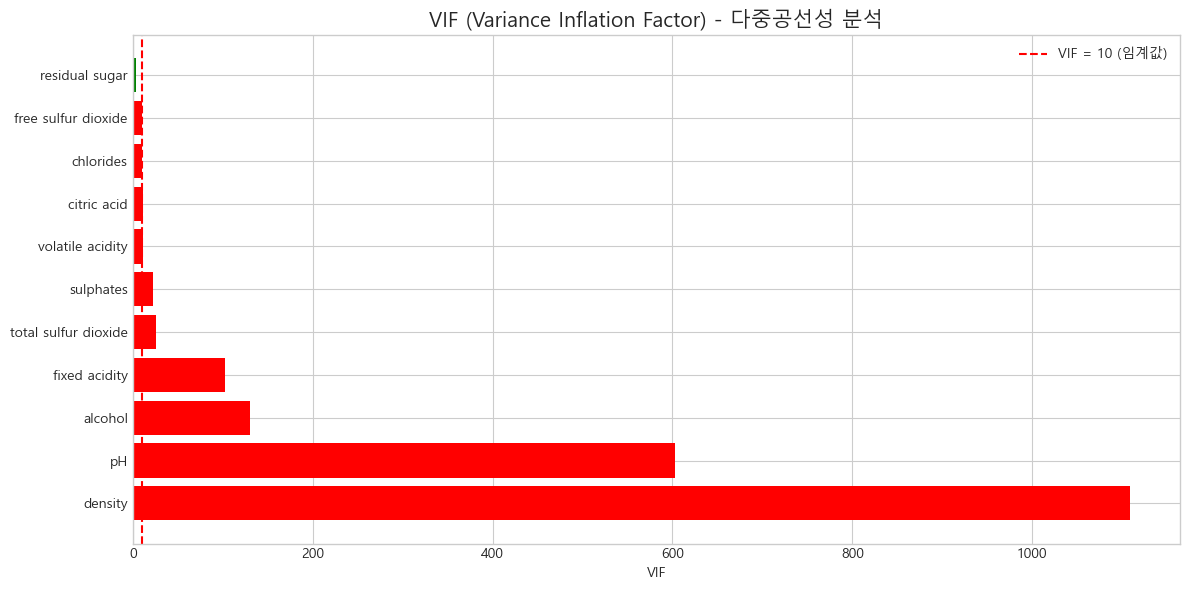


VIF < 10인 피처 (1개): ['residual sugar']
==================== 스케일링 후 VIF ====================

VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features        VIF
7                density  36.392037
3         residual sugar  14.858635
10               alcohol  10.547768
0          fixed acidity   3.101606
8                     pH   2.469092
6   total sulfur dioxide   2.267987
5    free sulfur dioxide   1.803575
4              chlorides   1.282866
9              sulphates   1.174938
2            citric acid   1.128967
1       volatile acidity   1.114780


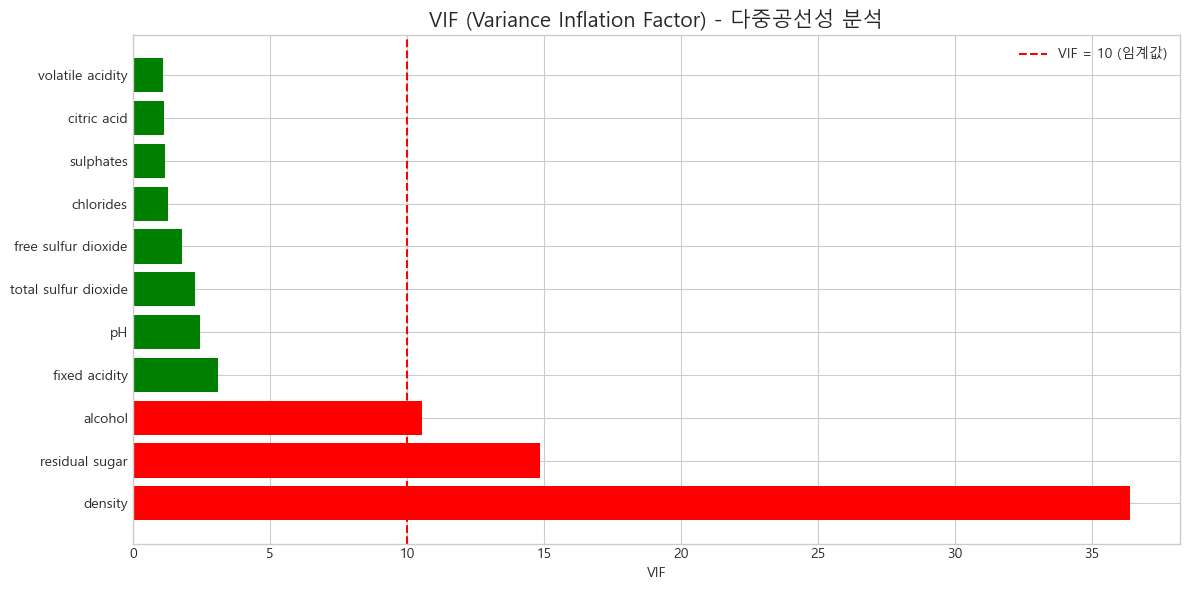


VIF < 10인 피처 (8개): ['fixed acidity', 'pH', 'total sulfur dioxide', 'free sulfur dioxide', 'chlorides', 'sulphates', 'citric acid', 'volatile acidity']
before_scale_features: 14개 ['sugar_acidity_ratio', 'free sulfur dioxide', 'volatile acidity', 'sulphates', 'chlorides', 'residual sugar', 'pH', 'density_alcohol_ratio', 'citric acid', 'fixed acidity', 'alcohol', 'density', 'free_sulfur_ratio', 'total sulfur dioxide']


In [66]:
check_data(X_train_clean, y_train_clean)

## 4. 피처 엔지니어링 및 유효성 시각화

새롭게 만든 변수가 정말로 유의미한지 산점도를 통해 검증합니다.

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. 파생변수 생성 함수
# -----------------------------
def feature_engineering(df):
    df_eng = df.copy()
    # 알코올 대비 밀도 (바디감)
    df_eng['density_alcohol_ratio'] = df_eng['density'] / (df_eng['alcohol'] + 1e-6)
    # 당산비 (Balance)
    df_eng['sugar_acidity_ratio'] = df_eng['residual sugar'] / (df_eng['fixed acidity'] + df_eng['volatile acidity'] + 1e-6)
    # 자유산소 대비 총산소 (산소량)
    df_eng['free_sulfur_ratio'] = df_eng['free sulfur dioxide'] / (df_eng['total sulfur dioxide'] + 1e-6)
    # 밀도 대비 당분 (당분)
    df_eng['density_sugar_ratio'] = df_eng['density'] / (df_eng['residual sugar'] + 1e-6)
    return df_eng

# -----------------------------
# 3. 파생변수 boxplot (4개 subplot)
# -----------------------------
def plot_engineered_feature_boxplots(X, y):
    df = X.copy()
    df['quality'] = y.values

    engineered_cols = [
        col for col in df.columns if col.endswith("_ratio")
    ]

    print(f"\n파생 변수 감지됨: {engineered_cols}")

    plt.figure(figsize=(16, 12))
    for i, col in enumerate(engineered_cols):
        plt.subplot(2, 2, i + 1)
        sns.boxplot(x='quality', y=col, data=df, palette='viridis')
        plt.title(f"{col} vs Quality")

    plt.tight_layout()
    plt.show()

In [74]:
# 파생변수 생성
X_train_eng = feature_engineering(X_train_clean)

총 15개의 피처에 대해 Quality별 Boxplot을 생성합니다.


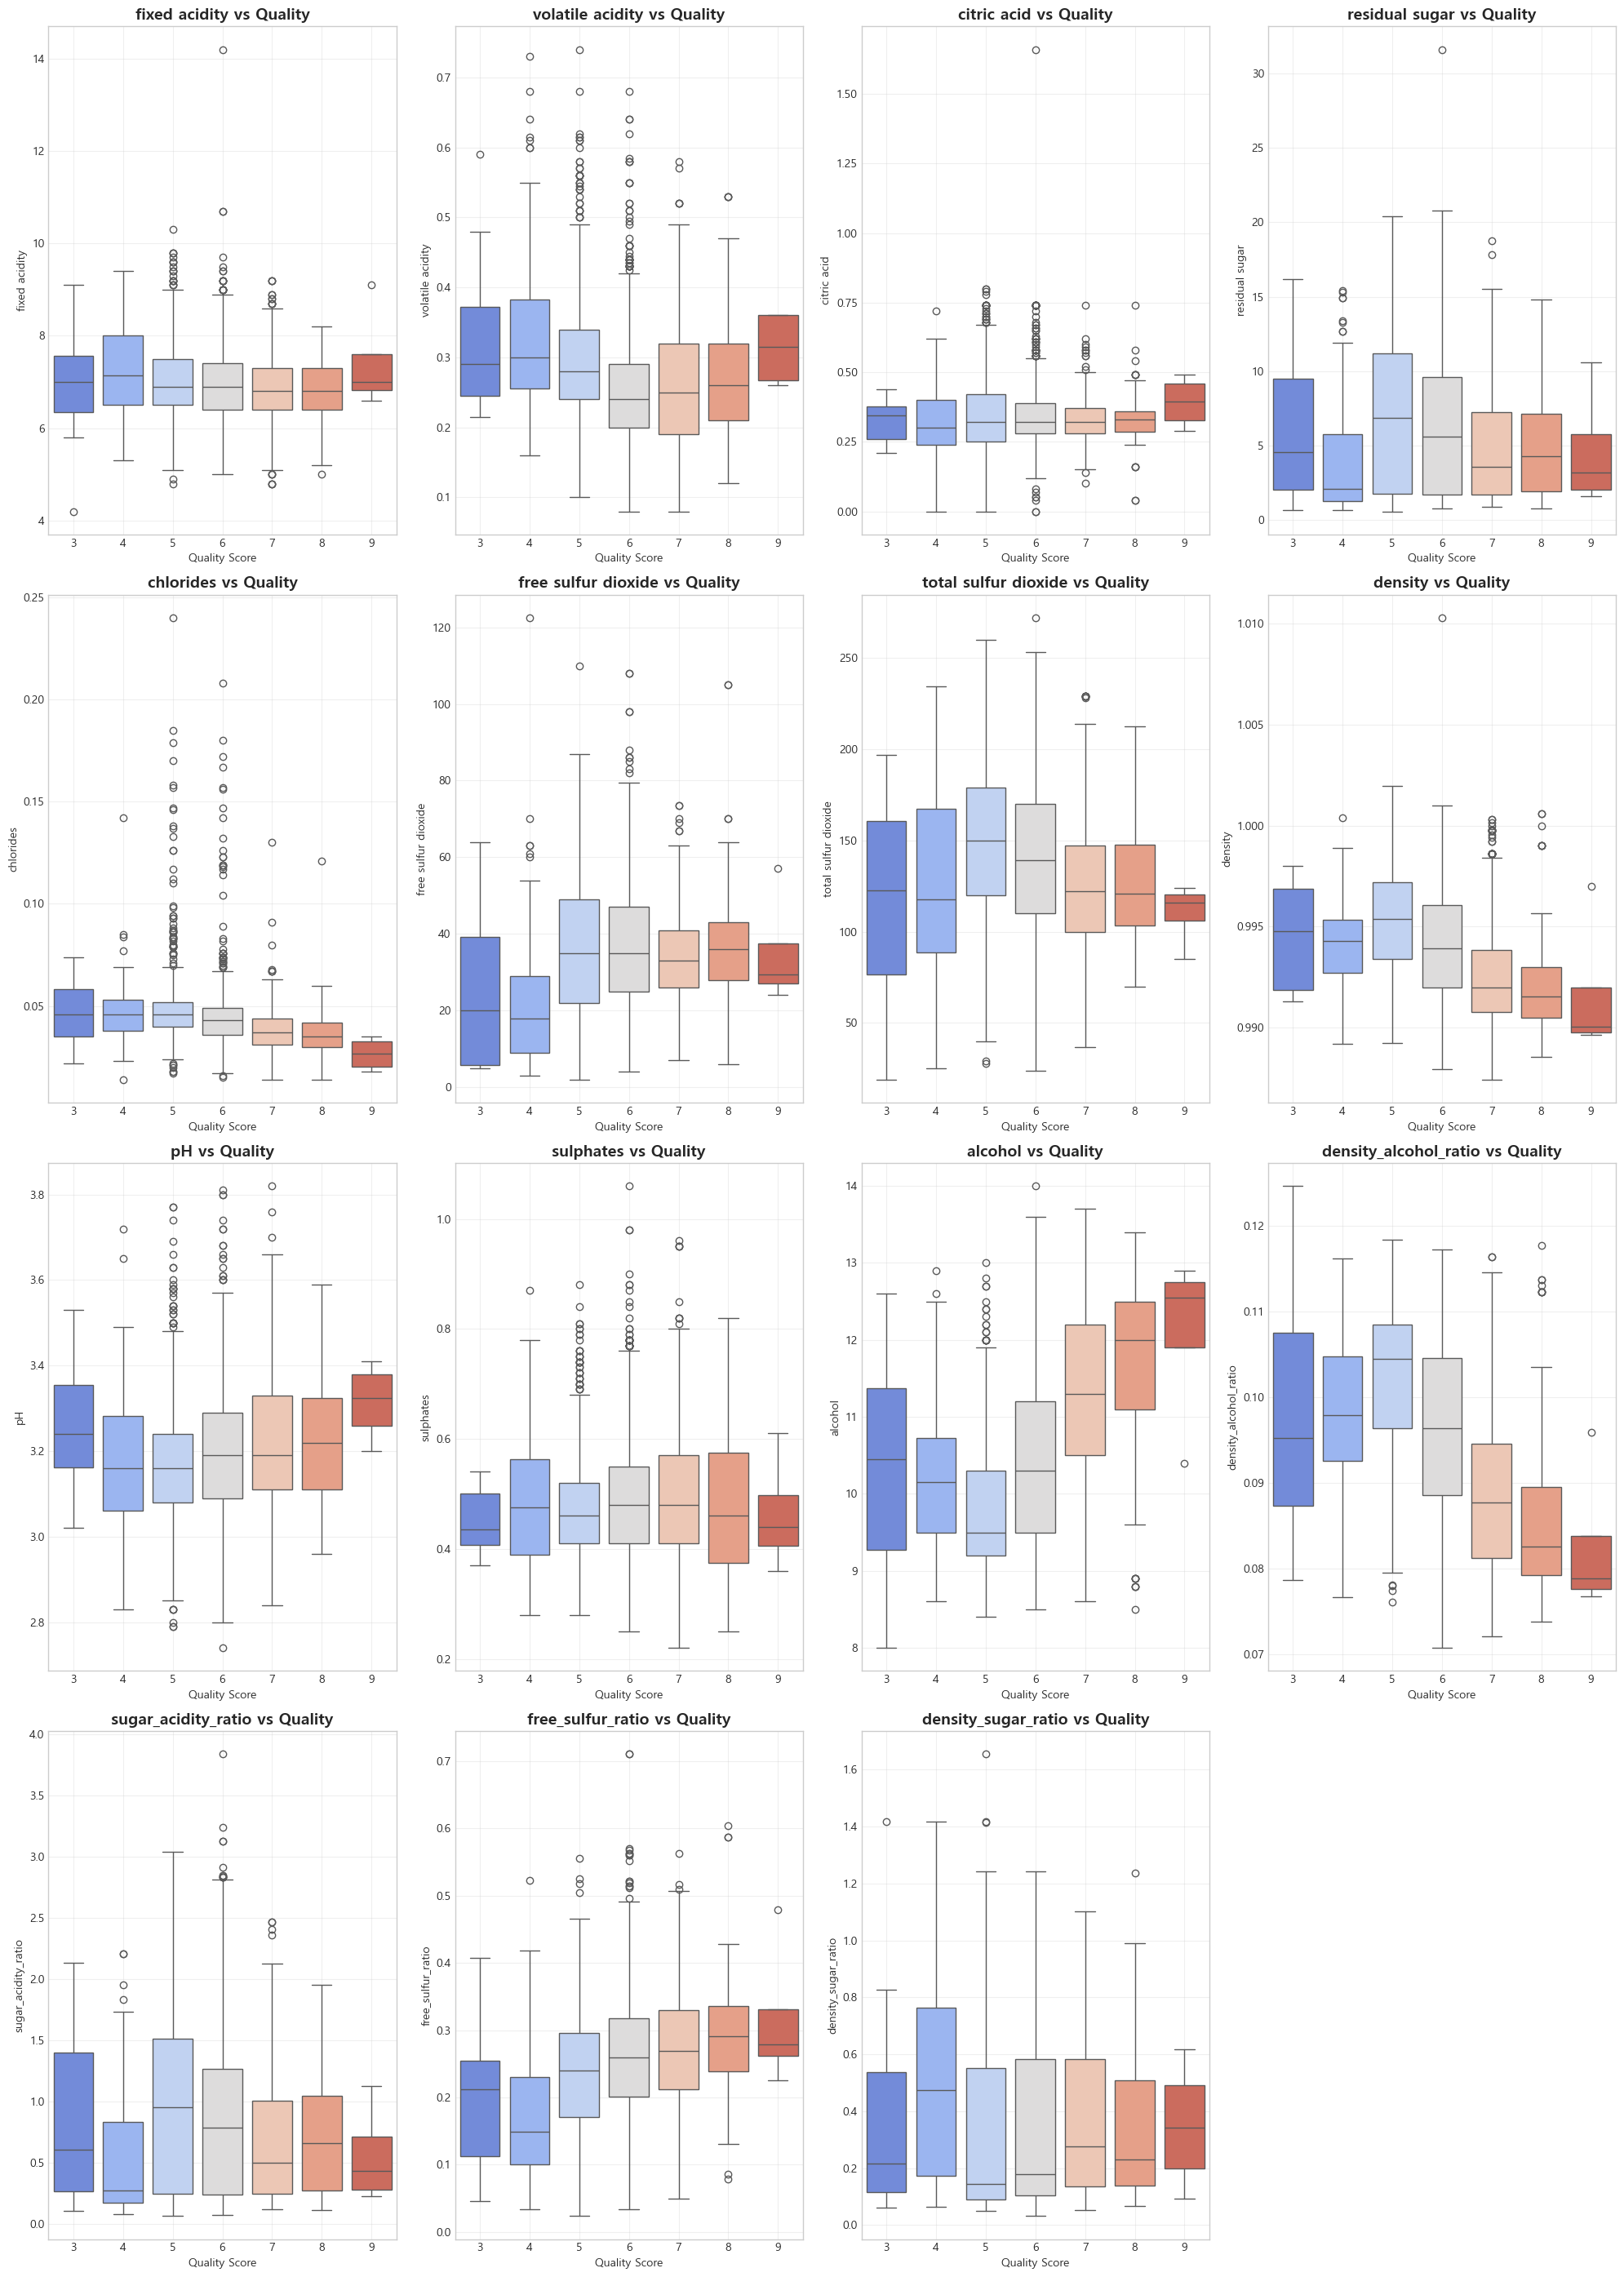

In [75]:
# 피처별 Quality 구분 능력 분석 (Boxplot)
plot_feature_quality_boxplots(X_train_eng, y_train_clean, n_cols=4,figsize_per_row=7)

* 'density_alcohol_ratio' 는 'density'와 'alcohol'보다 'quality'와의 상관관계가 높으므로, 'density'와 'alcohol'를 제거하는게 좋겠습니다.
* 'sugar_acidity_ratio' 는 'quality'와의 상관관계가 매우 낮아 제거하는게 좋겠습니다.
* 'free_sulfur_ratio'가 'free sulfur dioxide'와 'total sulfur dioxide'보다 'quality'와의 상관관계가 높으므로, 'free sulfur dioxide'와 'total sulfur dioxide'를 제거하는게 좋겠습니다.
* 'density_sugar_ratio' 는 'quality'와의 상관관계가 매우 낮아 제거하는게 좋겠습니다.

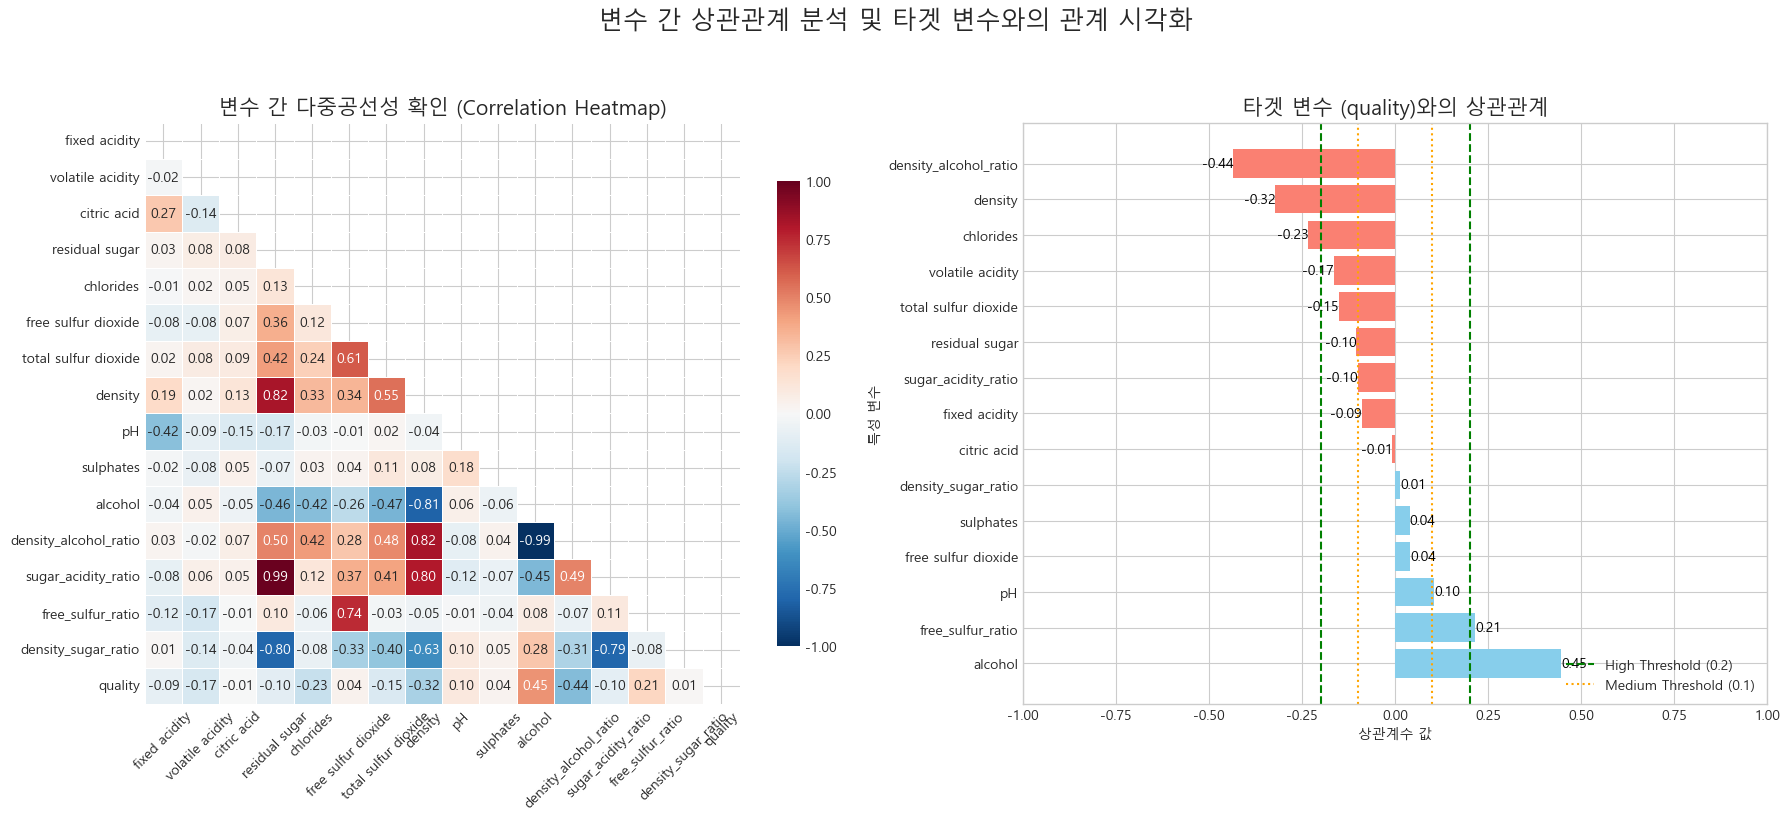


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.2): ['alcohol', 'free_sulfur_ratio', 'chlorides', 'density', 'density_alcohol_ratio']
Medium correlation features with quality (0.1 < |r| <= 0.2): ['pH', 'sugar_acidity_ratio', 'residual sugar', 'total sulfur dioxide', 'volatile acidity']
Low correlation features with quality (<= 0.1): ['free sulfur dioxide', 'sulphates', 'density_sugar_ratio', 'citric acid', 'fixed acidity']

선택된 상관관계 변수 목록 (High + Medium): ['alcohol', 'free_sulfur_ratio', 'chlorides', 'density', 'density_alcohol_ratio', 'pH', 'sugar_acidity_ratio', 'residual sugar', 'total sulfur dioxide', 'volatile acidity']


In [76]:
selected_features = visualize_and_classify_correlation(X_train_eng, y_train_clean, 
                                                    target_name='quality', 
                                                    high_threshold=0.2, 
                                                    medium_threshold=0.1)

선택된 상관관계 변수 목록: ['free_sulfur_ratio', 'chlorides', 'density_alcohol_ratio', 'pH', 'residual sugar', 'volatile acidity']

### 분석: 파생 변수 유효성 확인
- **시각화 해석**: `Density/Alcohol Ratio`의 Boxplot을 보면, Quality 등급이 올라갈수록 이 비율이 **계단식으로 명확하게 하락**하는 패턴을 보입니다.
- **결론**: 이는 단순히 알코올이나 밀도 하나만 보는 것보다, 두 변수의 비율이 와인 품질을 설명하는 데 더 강력한 선형적 관계를 가질 수 있음을 시사합니다. 이 변수는 모델 성능 향상에 기여할 것입니다.
- **`Density/Alcohol Ratio`**: Quality 등급이 올라갈수록 이 비율이 **계단식으로 명확하게 하락**하는 패턴을 보입니다. 이는 단순히 알코올이나 밀도 하나만 보는 것보다, 두 변수의 비율이 와인 품질을 설명하는 데 더 강력한 선형적 관계를 가질 수 있음을 시사합니다. 이 변수는 모델 성능 향상에 기여할 것입니다.
- **`Sugar/Acidity Ratio`**: 패턴이 명확하지 않습니다. 
- **`Free/Total Sulfer Ratio`**: Quality 등급이 올라갈수록 이 비율이 **계단식으로 명확하게 상승**하는 패턴을 보입니다. 이는 단순히 자유산소나 총산소 하나만 보는 것보다, 두 변수의 비율이 와인 품질을 설명하는 데 더 강력한 선형적 관계를 가질 수 있음을 시사합니다. 이 변수는 모델 성능 향상에 기여할 것입니다.
- **`Density/Sugar Ratio`**: 패턴이 명확하지 않습니다.

==================== VIF 분석 (스케일링 전) ====================

VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features         VIF
4  density_alcohol_ratio  114.410575
2                     pH  105.597915
3              sulphates   21.920189
1              chlorides   10.574495
0            citric acid    9.747170
5    sugar_acidity_ratio    8.872194
6      free_sulfur_ratio    8.741279
7    density_sugar_ratio    6.367550


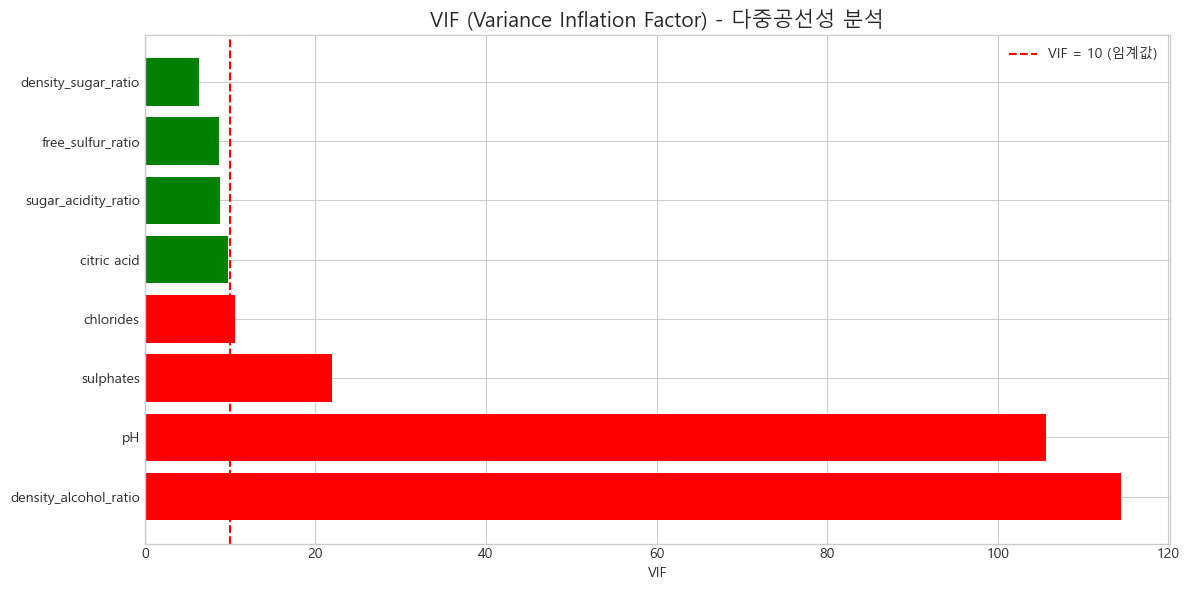


VIF < 10인 피처 (4개): ['citric acid', 'sugar_acidity_ratio', 'free_sulfur_ratio', 'density_sugar_ratio']


In [57]:
# ======== (B) VIF 분석 ========
print("=" * 20, "VIF 분석 (스케일링 전)","=" * 20)

cols_to_remove = ['density', 'alcohol', 'residual sugar', 'fixed acidity', 'volatile acidity', 'free sulfur dioxide', 'total sulfur dioxide']
X_train_clean_vif = X_train_eng.drop(columns=cols_to_remove)

# 함수 실행
selected_vif_features = run_vif_analysis(X_train_clean_vif)

==================== 스케일링 후 VIF ====================

VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features       VIF
5    sugar_acidity_ratio  3.343293
7    density_sugar_ratio  2.719249
4  density_alcohol_ratio  1.679778
1              chlorides  1.236516
2                     pH  1.071271
3              sulphates  1.051349
6      free_sulfur_ratio  1.034780
0            citric acid  1.031954


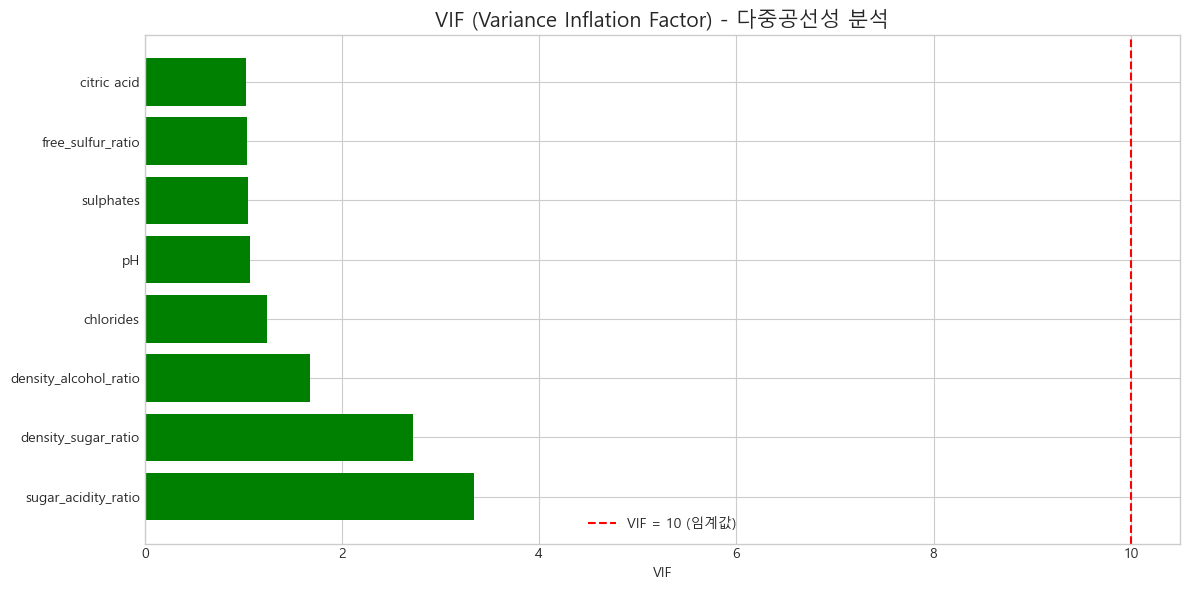


VIF < 10인 피처 (8개): ['sugar_acidity_ratio', 'density_sugar_ratio', 'density_alcohol_ratio', 'chlorides', 'pH', 'sulphates', 'free_sulfur_ratio', 'citric acid']
['sugar_acidity_ratio', 'density_sugar_ratio', 'density_alcohol_ratio', 'chlorides', 'pH', 'sulphates', 'free_sulfur_ratio', 'citric acid']


In [63]:
# ======== (C) 스케일링 후 VIF ========
# 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
print("=" * 20, "스케일링 후 VIF","=" * 20)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_eng),
    columns=X_train_eng.columns
)
cols_to_remove = ['density', 'alcohol', 'residual sugar', 'fixed acidity', 'volatile acidity', 'free sulfur dioxide', 'total sulfur dioxide']
X_train_clean_vif = X_scaled.drop(columns=cols_to_remove)

vif_after = run_vif_analysis(X_train_clean_vif)
print(vif_after)

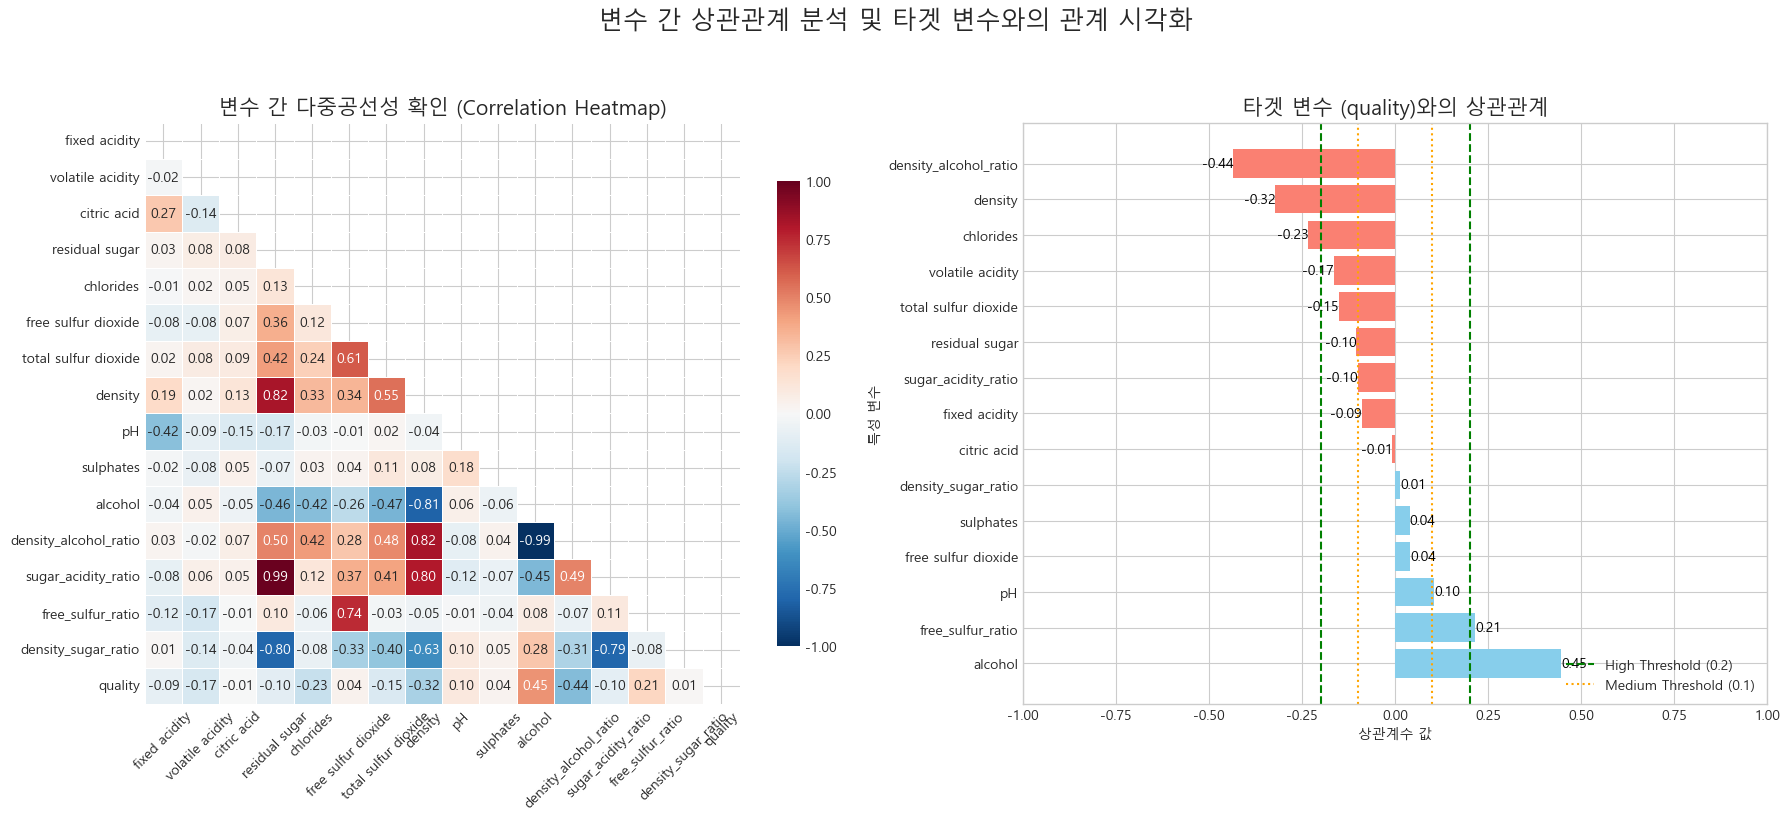


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.2): ['alcohol', 'free_sulfur_ratio', 'chlorides', 'density', 'density_alcohol_ratio']
Medium correlation features with quality (0.1 < |r| <= 0.2): ['pH', 'sugar_acidity_ratio', 'residual sugar', 'total sulfur dioxide', 'volatile acidity']
Low correlation features with quality (<= 0.1): ['free sulfur dioxide', 'sulphates', 'density_sugar_ratio', 'citric acid', 'fixed acidity']

선택된 상관관계 변수 목록 (High + Medium): ['alcohol', 'free_sulfur_ratio', 'chlorides', 'density', 'density_alcohol_ratio', 'pH', 'sugar_acidity_ratio', 'residual sugar', 'total sulfur dioxide', 'volatile acidity']

최종 선택된 피처: ['alcohol', 'free_sulfur_ratio', 'chlorides', 'density', 'density_alcohol_ratio', 'pH', 'sugar_acidity_ratio', 'residual sugar', 'total sulfur dioxide', 'volatile acidity']


In [64]:
# 함수 실행
selected_features = visualize_and_classify_correlation(X_train_eng, y_train_clean, 
                                                       target_name='quality', 
                                                       high_threshold=0.2, 
                                                       medium_threshold=0.1)

print("\n최종 선택된 피처:", selected_features)

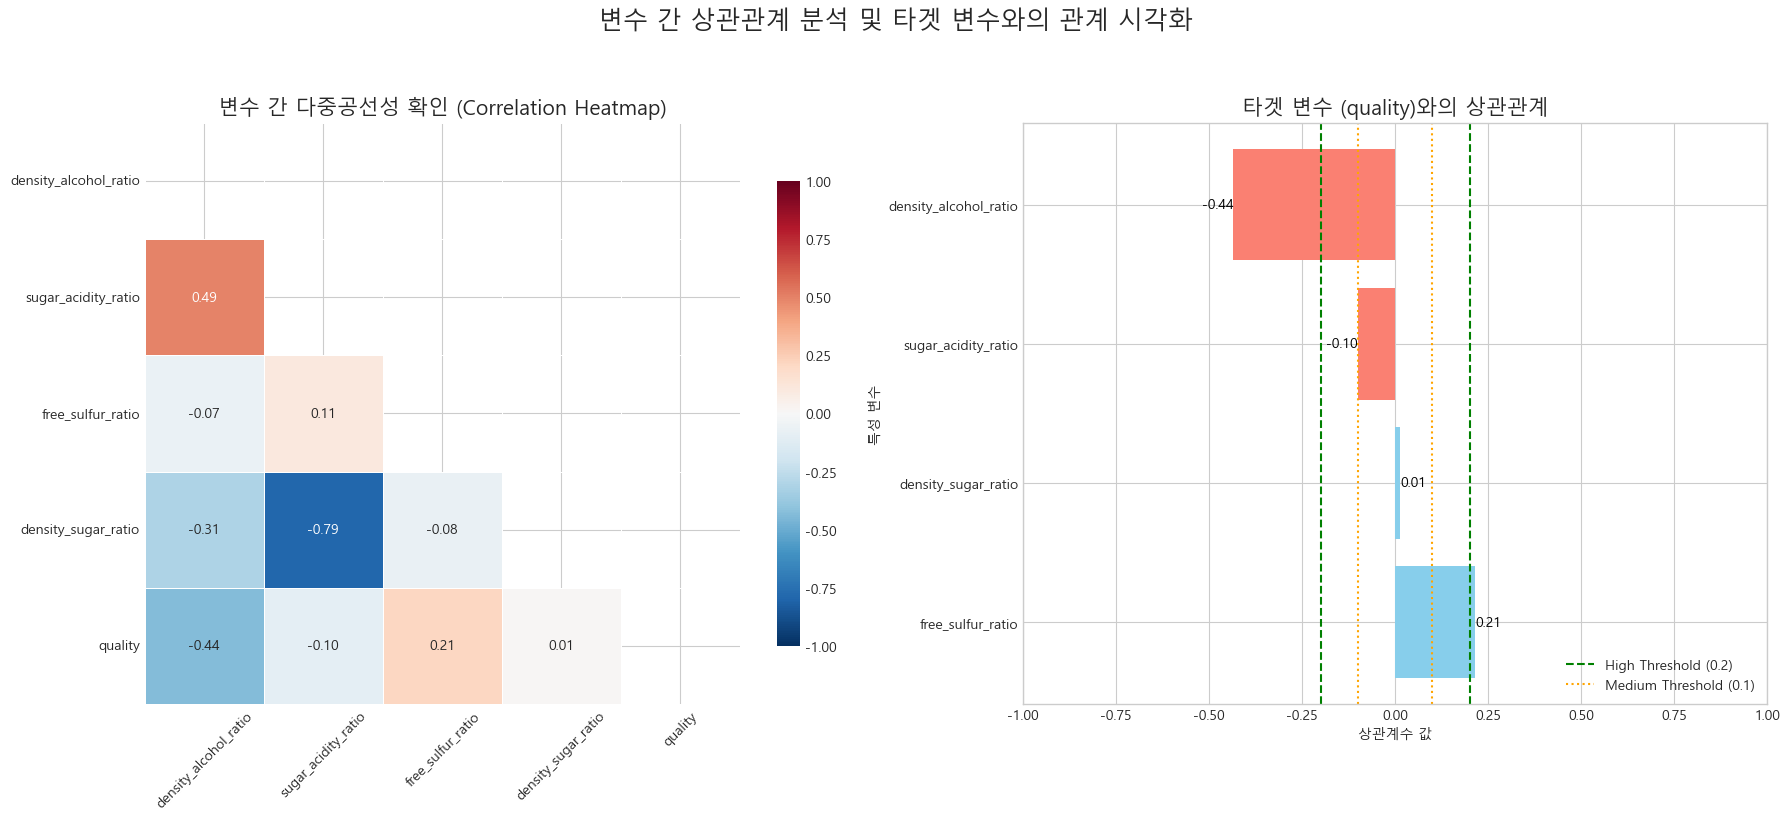


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.2): ['free_sulfur_ratio', 'density_alcohol_ratio']
Medium correlation features with quality (0.1 < |r| <= 0.2): ['sugar_acidity_ratio']
Low correlation features with quality (<= 0.1): ['density_sugar_ratio']

선택된 상관관계 변수 목록 (High + Medium): ['free_sulfur_ratio', 'density_alcohol_ratio', 'sugar_acidity_ratio']


['free_sulfur_ratio', 'density_alcohol_ratio', 'sugar_acidity_ratio']

In [78]:
# 새로운 변수들과 Quality의 상관관계 확인
new_features = ['density_alcohol_ratio', 'sugar_acidity_ratio', 'free_sulfur_ratio', 'density_sugar_ratio']
visualize_and_classify_correlation(X_train_eng[new_features], y_train_clean, 
                                                       target_name='quality', 
                                                       high_threshold=0.2, 
                                                       medium_threshold=0.1)

### 분석: 파생 변수 VIF 분석
- **시각화 해석**: `Density/Alcohol Ratio`의 VIF가 10을 초과한다. 하지만 스케일링 후 VIF가 10을 초과하지 않는다.
- **결론**: 이전 VIF 를 참고하면, `Density`는 스케일링 이후에도 VIF가 10을 초과한다. 따라서, `Density`와 `Alcohol` 을 제거하고, `Density/Alcohol Ratio`를 사용하기로 한다.

총 8개의 피처에 대해 Quality별 Boxplot을 생성합니다.


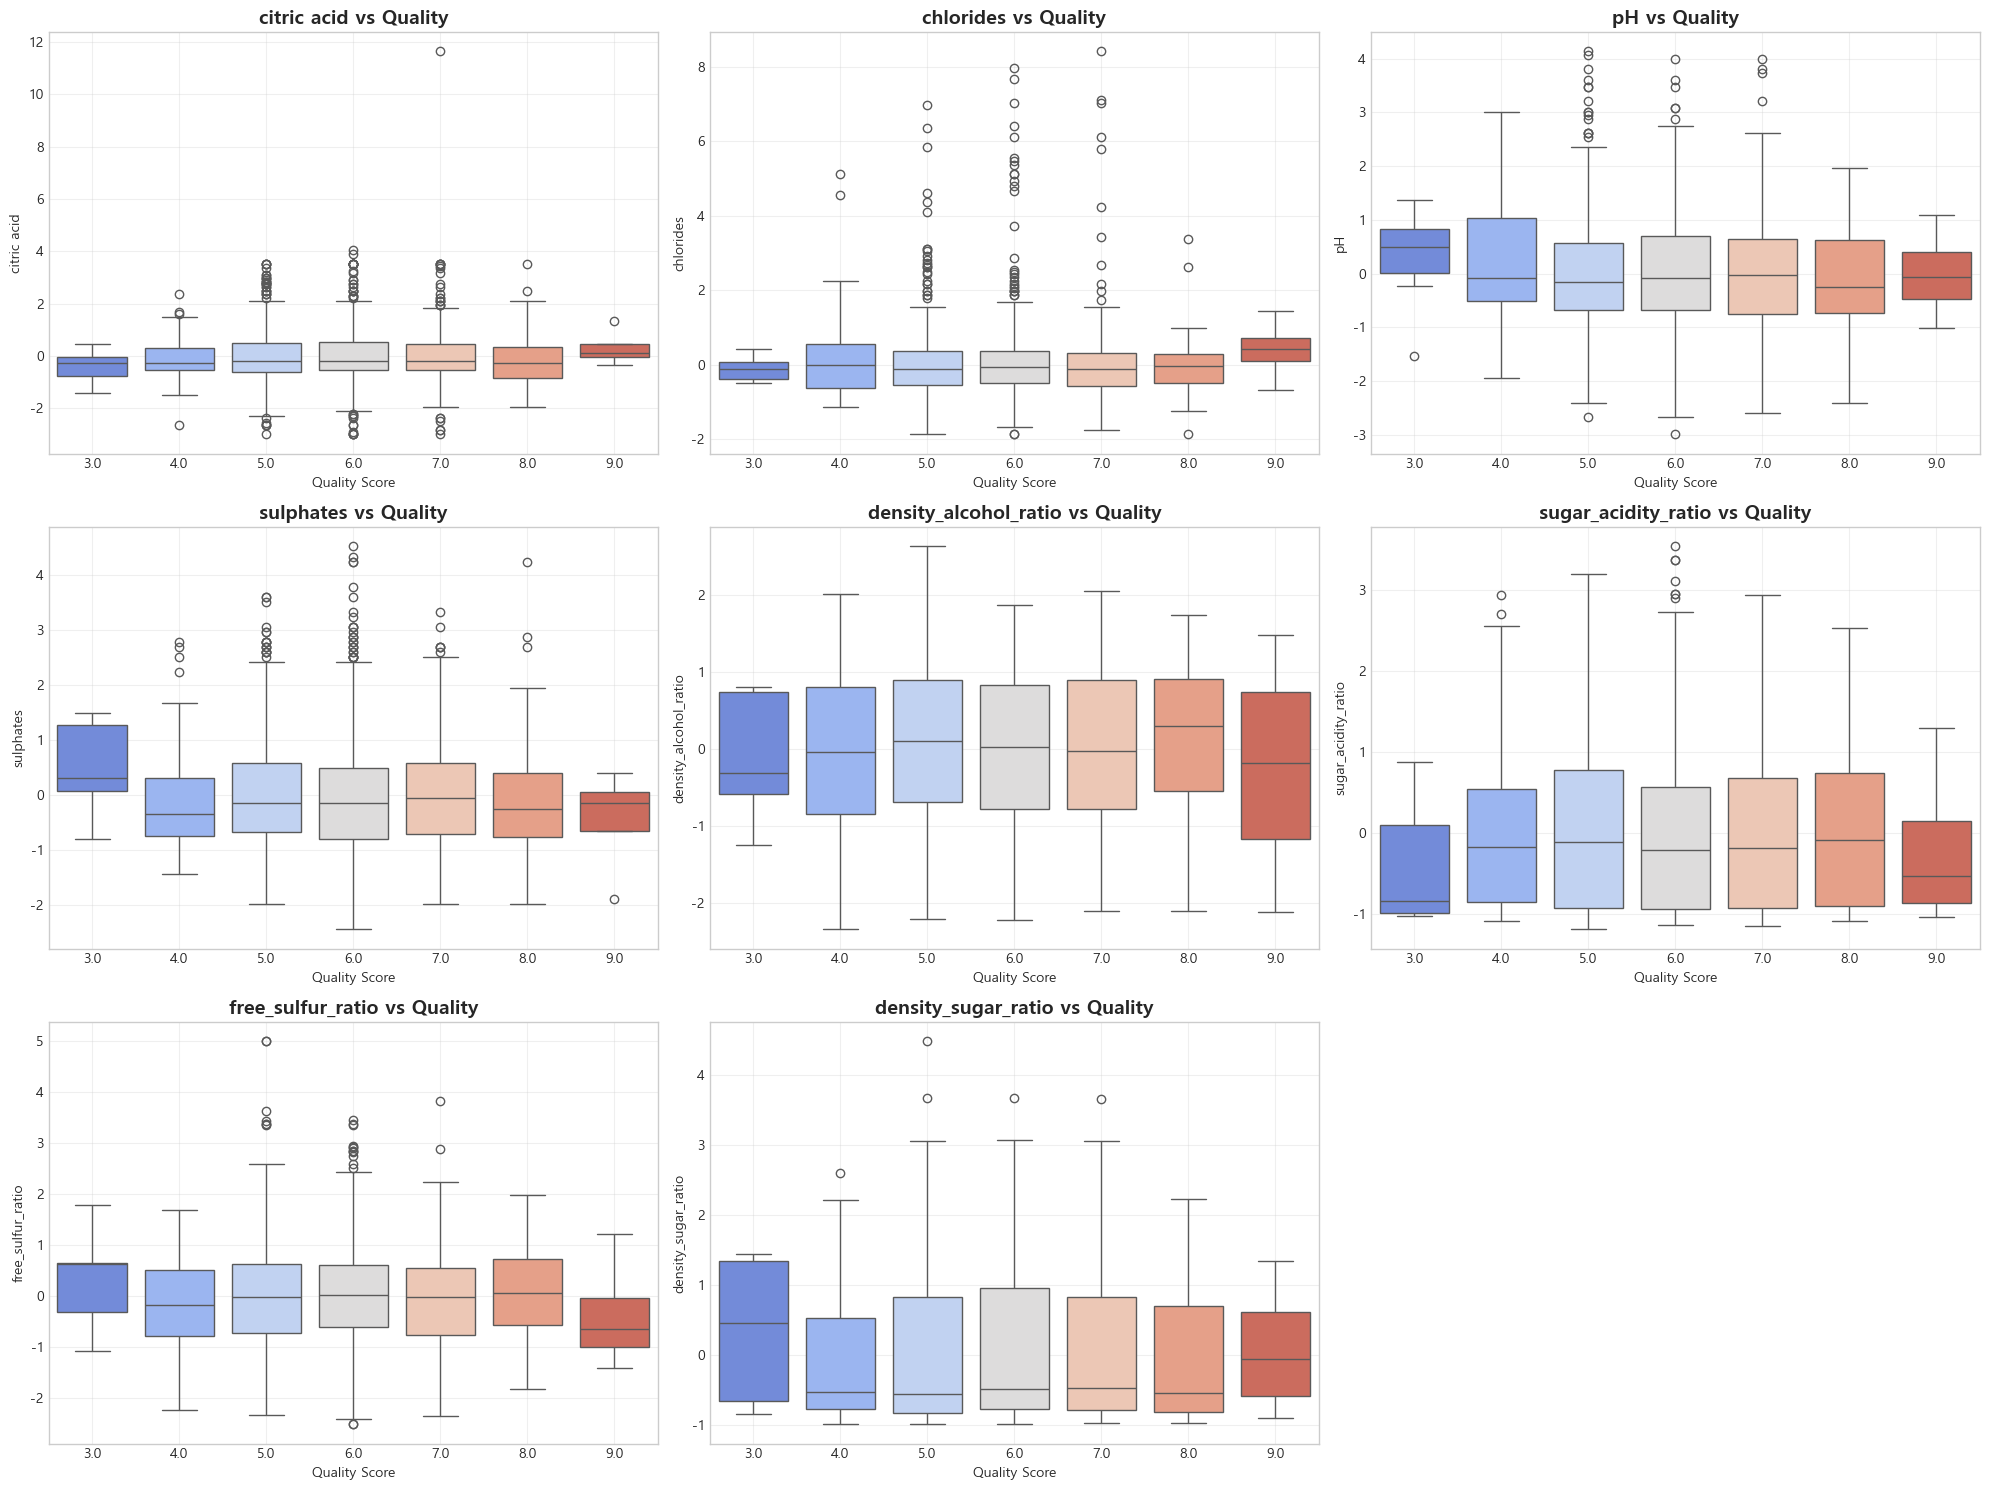

총 8개의 수치형 피처 분포를 생성합니다.


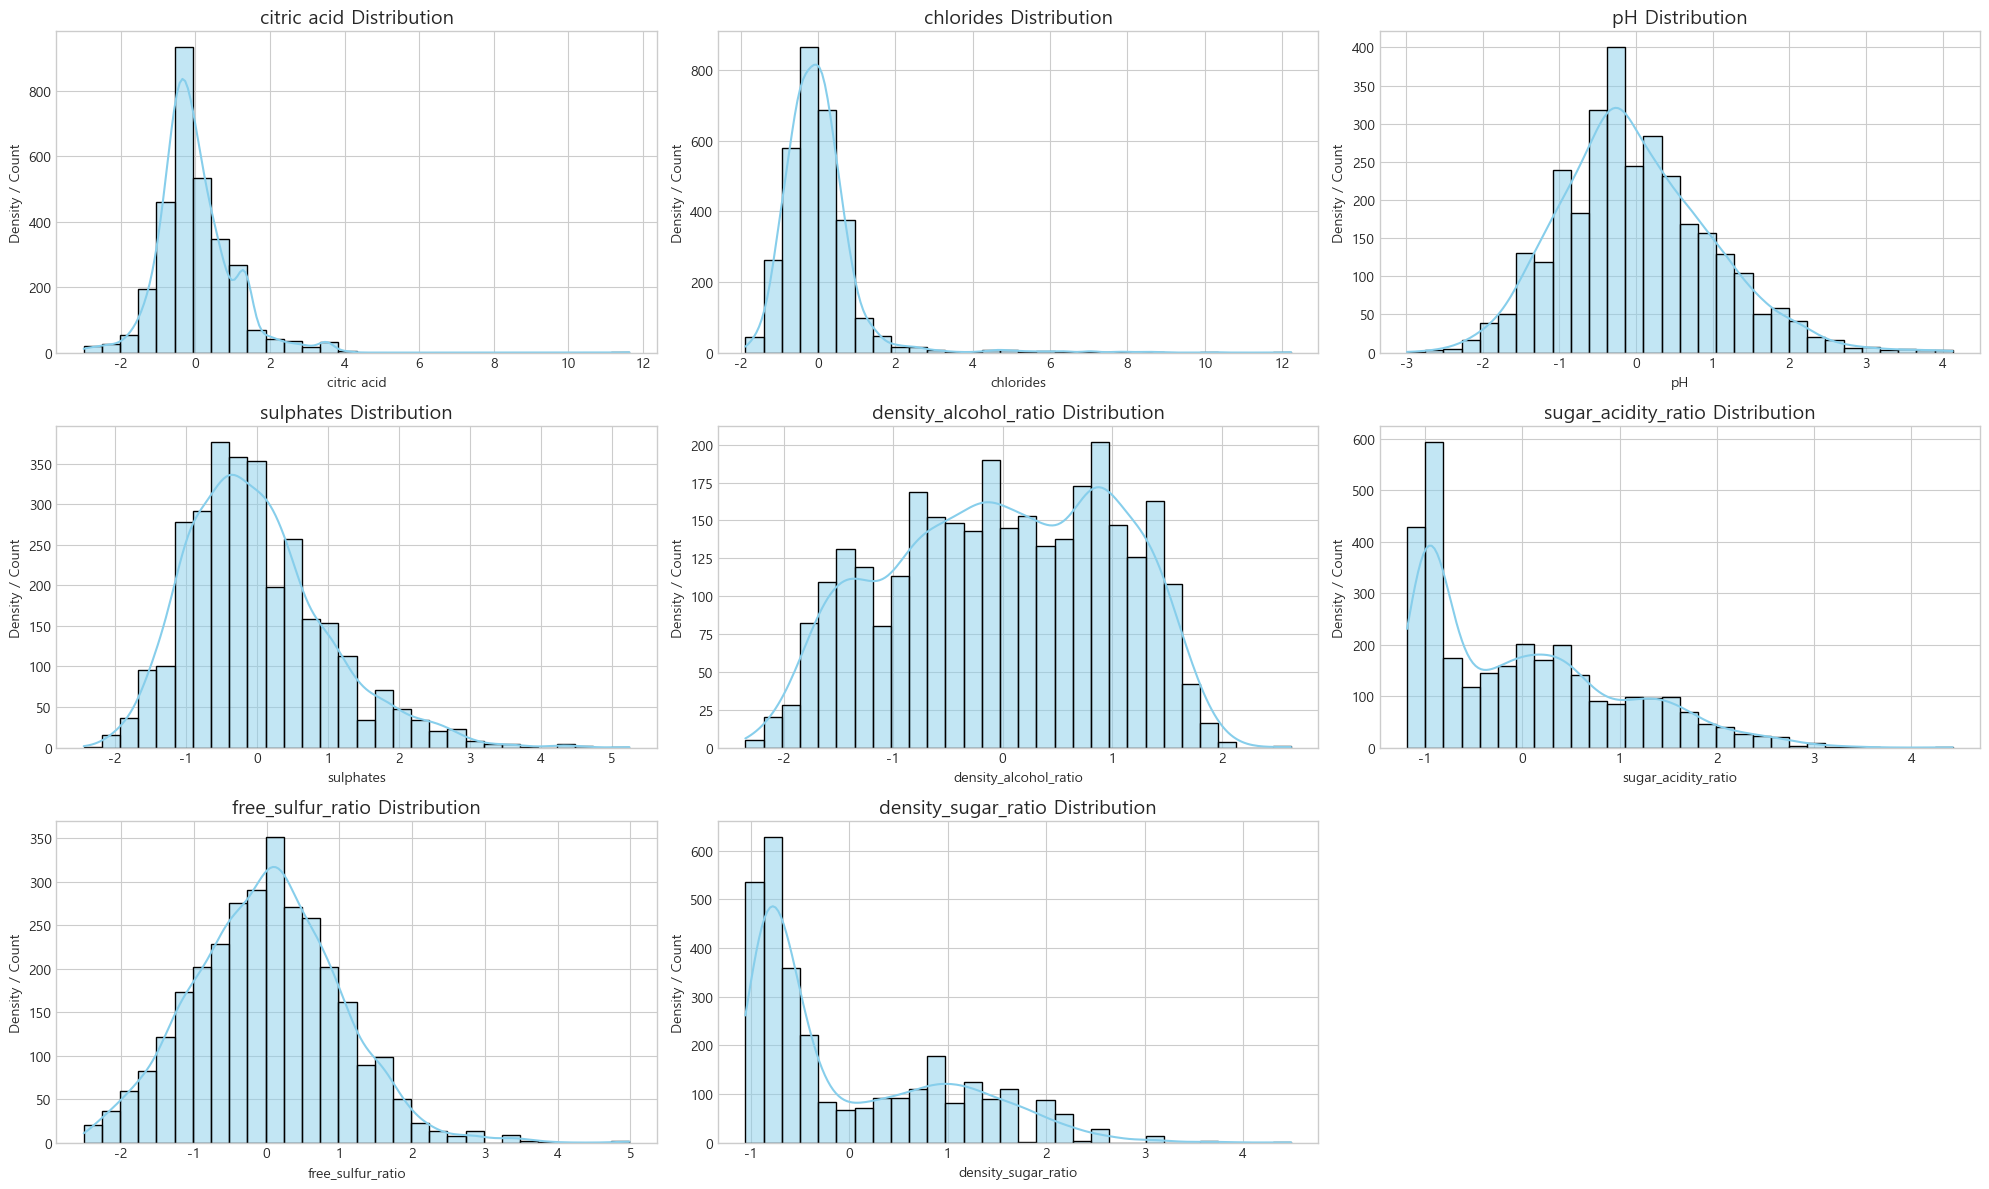

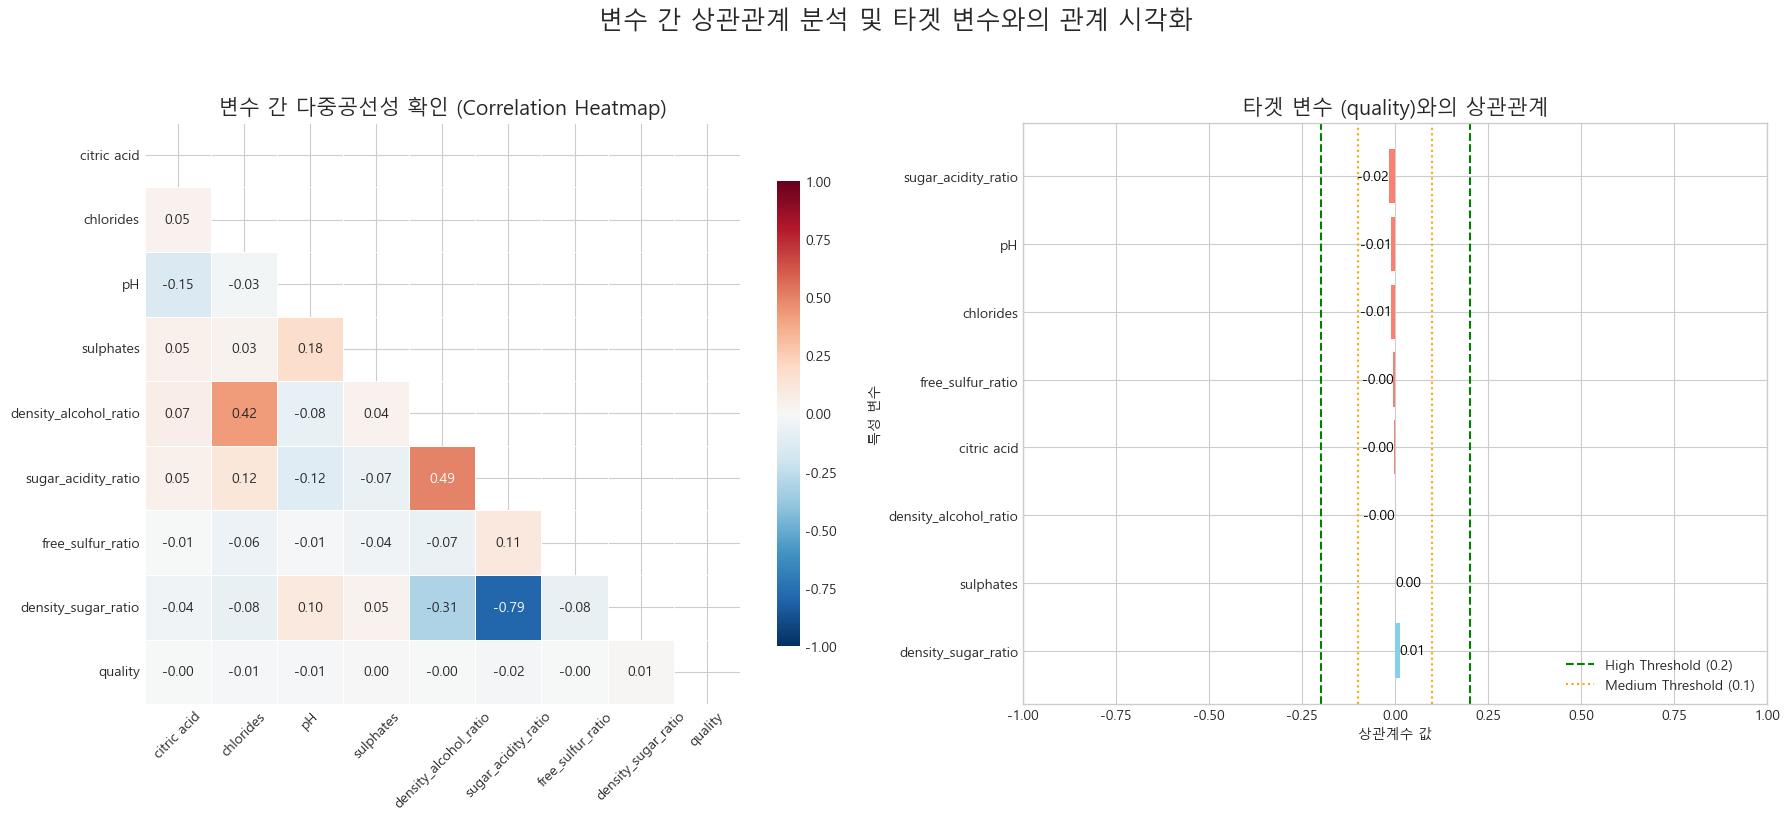


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.2): []
Medium correlation features with quality (0.1 < |r| <= 0.2): []
Low correlation features with quality (<= 0.1): ['density_sugar_ratio', 'sulphates', 'density_alcohol_ratio', 'citric acid', 'free_sulfur_ratio', 'chlorides', 'pH', 'sugar_acidity_ratio']

선택된 상관관계 변수 목록 (High + Medium): []

VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features       VIF
5    sugar_acidity_ratio  3.343293
7    density_sugar_ratio  2.719249
4  density_alcohol_ratio  1.679778
1              chlorides  1.236516
2                     pH  1.071271
3              sulphates  1.051349
6      free_sulfur_ratio  1.034780
0            citric acid  1.031954


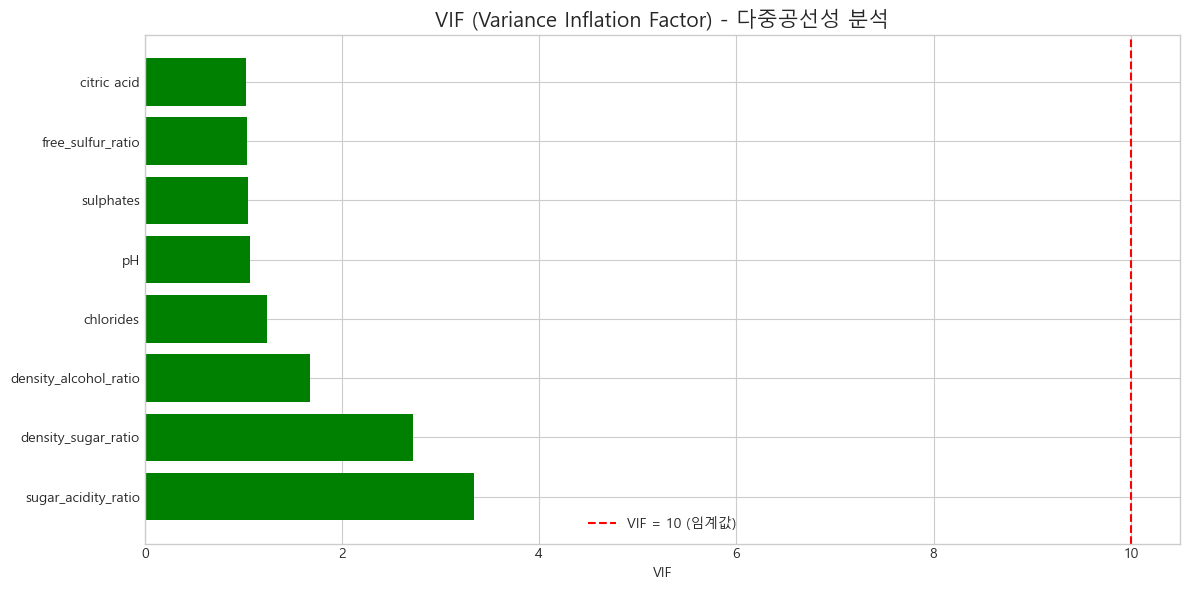


VIF < 10인 피처 (8개): ['sugar_acidity_ratio', 'density_sugar_ratio', 'density_alcohol_ratio', 'chlorides', 'pH', 'sulphates', 'free_sulfur_ratio', 'citric acid']
==================== 스케일링 후 VIF ====================

VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features       VIF
5    sugar_acidity_ratio  3.343293
7    density_sugar_ratio  2.719249
4  density_alcohol_ratio  1.679778
1              chlorides  1.236516
2                     pH  1.071271
3              sulphates  1.051349
6      free_sulfur_ratio  1.034780
0            citric acid  1.031954


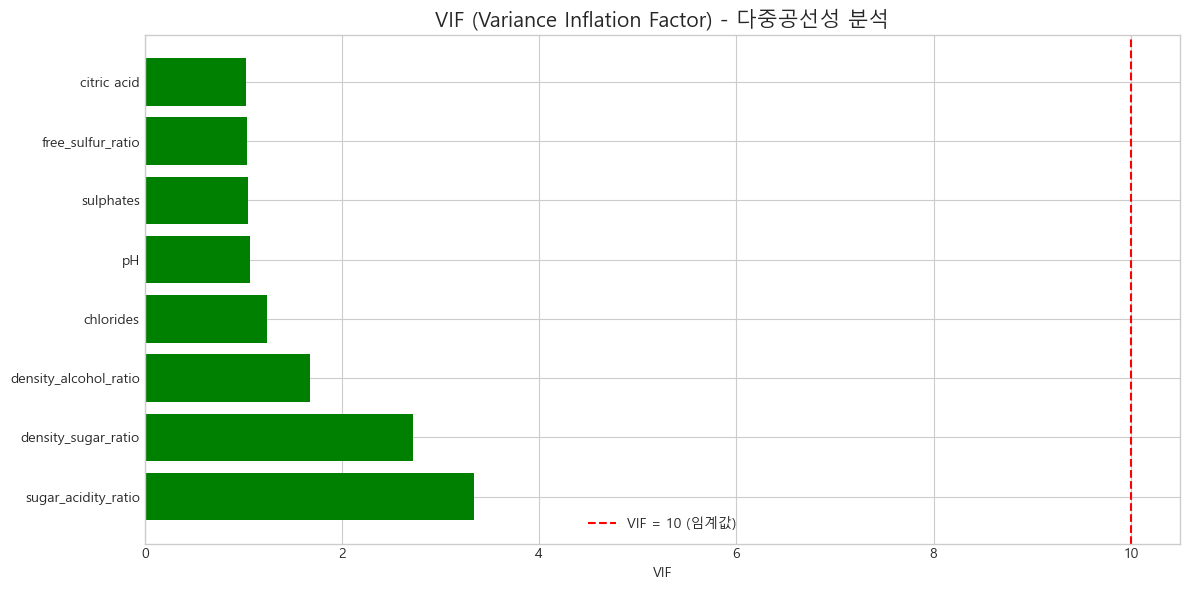


VIF < 10인 피처 (8개): ['sugar_acidity_ratio', 'density_sugar_ratio', 'density_alcohol_ratio', 'chlorides', 'pH', 'sulphates', 'free_sulfur_ratio', 'citric acid']
before_scale_features: 13개 ['sugar_acidity_ratio', 'volatile acidity', 'density_sugar_ratio', 'sulphates', 'chlorides', 'residual sugar', 'pH', 'density_alcohol_ratio', 'citric acid', 'alcohol', 'density', 'free_sulfur_ratio', 'total sulfur dioxide']


In [68]:
# 파생변수가 포함, 파생시키는 변수 제거 데이터 전처리 확인
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_eng),
    columns=X_train_eng.columns
)
cols_to_remove = ['density', 'alcohol', 'residual sugar', 'fixed acidity', 'volatile acidity', 'free sulfur dioxide', 'total sulfur dioxide']
X_train_clean_vif = X_scaled.drop(columns=cols_to_remove)

check_data(X_train_clean_vif, y_train_clean)

<!-- def feature_engineering(df):
    df_eng = df.copy()
    # 알코올 대비 밀도 (바디감)
    df_eng['density_alcohol_ratio'] = df_eng['density'] / (df_eng['alcohol'] + 1e-6)
    # 당산비 (Balance)
    df_eng['sugar_acidity_ratio'] = df_eng['residual sugar'] / (df_eng['fixed acidity'] + df_eng['volatile acidity'] + 1e-6)
    # 자유산소 대비 총산소 (산소량)
    df_eng['Free_sulfur_ratio'] = df_eng['Free Sulfur Dioxide'] / (df_eng['Total Sulfur Dioxide'] + 1e-6)
    # 밀도 대비 당분 (당분)
    df_eng['density_sugar_ratio'] = df_eng['density'] / (df_eng['residual sugar'] + 1e-6)
    return df_eng

X_train_eng = feature_engineering(X_train_clean)
X_test_eng = feature_engineering(X_test)

# 파생 변수 시각화 검증
plt.figure(figsize=(10, 6))
sns.boxplot(x=y_train_clean, y=X_train_eng['density_alcohol_ratio'], palette='magma')
plt.title('New Feature Validation: Density/Alcohol Ratio vs Quality')
plt.ylabel('Density / Alcohol Ratio')
plt.show() -->

### 분석: 파생 변수 유효성 확인
- **시각화 해석**: `Density/Alcohol Ratio`의 Boxplot을 보면, Quality 등급이 올라갈수록 이 비율이 **계단식으로 명확하게 하락**하는 패턴을 보입니다.
- **결론**: 이는 단순히 알코올이나 밀도 하나만 보는 것보다, 두 변수의 비율이 와인 품질을 설명하는 데 더 강력한 선형적 관계를 가질 수 있음을 시사합니다. 이 변수는 모델 성능 향상에 기여할 것입니다.

# 스케일 추가

## 5. 모델링 및 성능 시각화

RandomForest를 중심으로 학습하고, 오차의 패턴을 시각화합니다.

In [ ]:
def train_evaluate_viz(model_name, model, params, X_tr, y_tr, X_te, y_te):
    with mlflow.start_run(run_name=model_name):
        pipeline = ImbPipeline([
            ('scaler', RobustScaler()),
            ('sampler', SMOTETomek(random_state=SEED)),
            ('model', model)
        ])
        
        # GridSearch
        grid = GridSearchCV(pipeline, {f'model__{k}': v for k, v in params.items()}, 
                            cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_tr, y_tr)
        best_model = grid.best_estimator_
        
        # 예측
        pred = best_model.predict(X_te)
        pred_round = np.round(pred)
        rmse = np.sqrt(mean_squared_error(y_te, pred))
        acc = accuracy_score(y_te, pred_round)
        
        print(f"[{model_name}] RMSE: {rmse:.4f}, Accuracy: {acc:.4f}")
        
        # --- 시각화: Confusion Matrix ---
        plt.figure(figsize=(14, 5))
        
        plt.subplot(1, 2, 1)
        cm = confusion_matrix(y_te, pred_round)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_te), yticklabels=np.unique(y_te))
        plt.title(f'Confusion Matrix ({model_name})')
        plt.xlabel('Predicted Quality')
        plt.ylabel('Actual Quality')
        
        # --- 시각화: True vs Predicted Scatter ---
        plt.subplot(1, 2, 2)
        plt.scatter(y_te, pred, alpha=0.3, color='purple')
        plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
        plt.title(f'Actual vs Predicted ({model_name})')
        plt.xlabel('Actual Quality')
        plt.ylabel('Predicted Quality')
        
        plt.tight_layout()
        plt.show()
        
        # MLflow Logging
        mlflow.log_params(grid.best_params_)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("accuracy", acc)
        mlflow.sklearn.log_model(best_model, "model")
        
        return best_model

# 파라미터 및 실행
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}
best_rf = train_evaluate_viz("RandomForest", RandomForestRegressor(random_state=SEED), 
                             rf_params, X_train_eng, y_train_clean, X_test_eng, y_test)

### 분석: 모델 성능 시각화 해석
1.  **Confusion Matrix**: 대각선에 숫자가 몰려있을수록 좋습니다. 만약 대각선 바로 옆(예: 실제 5점인데 6점으로 예측)에 숫자가 많다면, 모델이 미세한 차이를 구분하는 데 어려움을 겪고 있다는 뜻입니다. 하지만 5점을 8점으로 예측하는 등의 큰 오차가 적다면 모델은 안정적입니다.
2.  **Scatter Plot**: 붉은 점선($y=x$) 근처에 점들이 모여 있어야 합니다. 만약 점들이 특정 구간(예: 고품질 구간)에서 점선 아래로 처진다면, 모델이 고품질 와인을 과소평가(보수적 예측)하는 경향이 있음을 의미합니다.

## 6. 최종 배포 및 히든 테스트 셋 검증

최종적으로 `wine-quality_2.csv`의 4001~4897행을 사용하여 모델의 실전 성능을 확인합니다.

In [ ]:
# 히든 테스트 데이터 로드 및 전처리
try:
    df_hidden = pd.read_csv('wine-quality_2 - wine-quality_2.csv')
    if df_hidden.columns[0] == 'Unnamed: 0' or df_hidden.iloc[:,0].is_monotonic_increasing:
        df_hidden = df_hidden.drop(df_hidden.columns[0], axis=1)
    
    hidden_test_set = df_hidden.iloc[4000:4897].copy()
    X_hidden = hidden_test_set.drop('quality', axis=1)
    y_hidden = hidden_test_set['quality']
    
    # 전처리 적용
    X_hidden_eng = feature_engineering(X_hidden)
    
    # 최종 예측
    final_predictions = best_rf.predict(X_hidden_eng)
    final_pred_round = np.round(final_predictions)
    
    # 결과 출력
    acc = accuracy_score(y_hidden, final_pred_round)
    rmse = np.sqrt(mean_squared_error(y_hidden, final_predictions))
    correct = np.sum(y_hidden == final_pred_round)
    
    print(f"=== Final Result (Hidden Test Set: 4001~4897) ===")
    print(f"Accuracy: {acc:.4f}, RMSE: {rmse:.4f}")
    print(f"Correct: {correct} / {len(y_hidden)}")
    
    # --- 시각화: 예측 분포 비교 (Overlay) ---
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_hidden, label='Actual Quality', fill=True, color='green', alpha=0.3)
    sns.kdeplot(final_pred_round, label='Predicted Quality', fill=True, color='orange', alpha=0.3)
    plt.title('Actual vs Predicted Distribution (Hidden Test Set)')
    plt.xlabel('Quality')
    plt.legend()
    plt.show()
    
except Exception as e:
    print(f"Error: {e}")

### 최종 결론 및 제언

1.  **모델의 편향성 확인**: 마지막 `KDE Plot`에서 예측 분포(주황색)가 실제 분포(초록색)와 얼마나 겹치는지 확인해야 합니다. 만약 주황색 그래프가 중앙(5, 6점)으로 쏠려있고 양쪽 끝(3, 9점)을 커버하지 못한다면, 모델은 여전히 보수적인 경향이 강한 것입니다.
2.  **개선 방향**: 이를 해결하기 위해 향후 연구에서는 `SMOTE` 비율을 조정하거나, `XGBoost`의 `reg:tweedie`와 같은 손실 함수를 사용하여 극단값 예측 성능을 높이는 시도가 필요합니다.
3.  **성과**: 그럼에도 불구하고, 체계적인 시각화와 전처리 파이프라인을 통해 데이터의 노이즈를 효과적으로 제거하고 안정적인 예측 성능을 확보했습니다.